# double_wg_supermode.ipynb

Double 220 nm silicon waveguide supermode analysis using Lumerical MODE/FDE.

Workflow:

1. Check Palik material dispersion for Si and SiO2 from 1500 nm to 1600 nm.
2. Build two 220 nm thick silicon strip waveguides in SiO2.
3. The two waveguides are centered symmetrically around x = 0.
4. The user sets the gap.
4. The user sets the gap.
5. Use symmetry reduction:
    - x min = Symmetric gives the even supermode.
    - x min = Antisymmetric gives the odd supermode.
    - y min = Symmetric selects the vertically TE-like symmetry.
6. Extract the first TE-like even and odd modes.
7. Compute:
    - n_even
    - n_odd
    - delta_n = |n_even - n_odd|
    - beat length L_pi = lambda / delta_n
    - 50/50 coupling length L_50_50 = L_pi / 4
8. Save the results.

## Imports and Lumerical API path

In [1]:
import os
import sys
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this to your Lumerical installation path
# Examples:
# r"C:\Program Files\Lumerical\v242\api\python"
# r"C:\Program Files\AnsysEM\v251\Lumerical\api\python"
# r"C:\Program Files\Lumerical\v261\api\python"

LUMERICAL_PYTHON_API = r"C:\Program Files\Lumerical\v261\api\python"

if not os.path.isdir(LUMERICAL_PYTHON_API):
    raise FileNotFoundError(
        f"Lumerical Python API folder not found:\n{LUMERICAL_PYTHON_API}"
    )

if LUMERICAL_PYTHON_API not in sys.path:
    sys.path.append(LUMERICAL_PYTHON_API)

import lumapi

print("lumapi imported successfully")

lumapi imported successfully


## Settings cell

In [2]:
settings = {
    # ------------------------------------------------------------------
    # Built-in Lumerical Palik materials
    # ------------------------------------------------------------------
    "si_material_name": "Si (Silicon) - Palik",
    "sio2_material_name": "SiO2 (Glass) - Palik",

    # ------------------------------------------------------------------
    # Material fitting range, like Material Explorer / MODE MCM fit
    # ------------------------------------------------------------------
    "material_fit_min_nm": 1200.0,
    "material_fit_max_nm": 1700.0,

    # ------------------------------------------------------------------
    # Design wavelength range for plotting and material analysis
    # ------------------------------------------------------------------
    "lambda_min_nm": 1500.0,
    "lambda_max_nm": 1600.0,
    "lambda_points": 501,

    # ------------------------------------------------------------------
    # Main simulation wavelength
    # ------------------------------------------------------------------
    "wavelength_um": 1.55,

    # ------------------------------------------------------------------
    # Double waveguide geometry
    # Propagation direction = z
    # Cross section = x-y
    #
    # Width = 0.500 um = 500 nm
    # Thickness = 0.220 um = 220 nm
    # Gap is edge-to-edge distance between waveguides
    # ------------------------------------------------------------------
    "wg_width_um": 0.500,
    "wg_thickness_um": 0.220,
    "gap_um": 0.150,

    "wg_center_y_um": 0.0,

    # ------------------------------------------------------------------
    # SiO2 surrounding box
    # ------------------------------------------------------------------
    "oxide_x_span_um": 50.0,
    "oxide_y_span_um": 50.0,
    "z_span_um": 10.0,

    # ------------------------------------------------------------------
    # FDE region
    #
    # Full cross-section simulation.
    # FDE is centered at x = 0, y = 0.
    # Do not set x min manually.
    # ------------------------------------------------------------------
    "fde_x_span_um": 15.0,
    "fde_y_span_um": 15.0,
    "fde_center_x_um": 0.0,
    "fde_center_y_um": 0.0,

    # Options:
    # "PML"   -> final open-boundary mode calculation
    # "Metal" -> quick bounded test
    "fde_bc": "PML",

    # ------------------------------------------------------------------
    # FDE mesh
    # ------------------------------------------------------------------
    "fde_dx_um": 0.05,
    "fde_dy_um": 0.05,
    "number_of_trial_modes": 2,

    # ------------------------------------------------------------------
    # TE mode filtering
    # ------------------------------------------------------------------
    "te_fraction_min": 0.5,

    # ------------------------------------------------------------------
    # Optional extra mesh around both waveguides
    # ------------------------------------------------------------------
    "use_extra_mesh": True,
    "extra_mesh_name": "mesh_double_wg",
    "mesh_x_margin_um": 0.30,
    "mesh_y_margin_um": 0.30,
    "local_dx_um": 0.01,
    "local_dy_um": 0.01,

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    "plot_window_x_um": (-2.0, 2.0),
    "plot_window_y_um": (-1.5, 1.5),
    "field_cut_x_um": 0.0,
    "field_cut_y_um": 0.0,
    "cmap": "jet",

    # Options:
    # "E2", "Sz", "W"
    "area_definition_for_metrics": "E2",

    # ------------------------------------------------------------------
    # Session
    # ------------------------------------------------------------------
    "hide_lumerical": False,

    # ------------------------------------------------------------------
    # Saving
    # ------------------------------------------------------------------
    "folder_name": "double_wg_supermode",
    "simulation_file_name": "double_si_wg_supermode_fde",
}

um = 1e-6
c0 = 299792458.0
eps0 = 8.854187817e-12
mu0 = 4 * np.pi * 1e-7

# ------------------------------------------------------------------
# Derived waveguide centers
# ------------------------------------------------------------------
settings["left_wg_center_x_um"] = -0.5 * settings["gap_um"] - 0.5 * settings["wg_width_um"]
settings["right_wg_center_x_um"] = +0.5 * settings["gap_um"] + 0.5 * settings["wg_width_um"]

settings["coupler_total_width_um"] = (
    2.0 * settings["wg_width_um"] + settings["gap_um"]
)

settings

{'si_material_name': 'Si (Silicon) - Palik',
 'sio2_material_name': 'SiO2 (Glass) - Palik',
 'material_fit_min_nm': 1200.0,
 'material_fit_max_nm': 1700.0,
 'lambda_min_nm': 1500.0,
 'lambda_max_nm': 1600.0,
 'lambda_points': 501,
 'wavelength_um': 1.55,
 'wg_width_um': 0.5,
 'wg_thickness_um': 0.22,
 'gap_um': 0.15,
 'wg_center_y_um': 0.0,
 'oxide_x_span_um': 50.0,
 'oxide_y_span_um': 50.0,
 'z_span_um': 10.0,
 'fde_x_span_um': 15.0,
 'fde_y_span_um': 15.0,
 'fde_center_x_um': 0.0,
 'fde_center_y_um': 0.0,
 'fde_bc': 'PML',
 'fde_dx_um': 0.05,
 'fde_dy_um': 0.05,
 'number_of_trial_modes': 2,
 'te_fraction_min': 0.5,
 'use_extra_mesh': True,
 'extra_mesh_name': 'mesh_double_wg',
 'mesh_x_margin_um': 0.3,
 'mesh_y_margin_um': 0.3,
 'local_dx_um': 0.01,
 'local_dy_um': 0.01,
 'plot_window_x_um': (-2.0, 2.0),
 'plot_window_y_um': (-1.5, 1.5),
 'field_cut_x_um': 0.0,
 'field_cut_y_um': 0.0,
 'cmap': 'jet',
 'area_definition_for_metrics': 'E2',
 'hide_lumerical': False,
 'folder_name': 'dou

## Helper checks

In [3]:
def check_boundary_condition_name(bc):
    allowed = ["PML", "Metal"]
    if bc not in allowed:
        raise ValueError(f"Invalid fde_bc = {bc}. Use one of {allowed}.")


check_boundary_condition_name(settings["fde_bc"])

if abs(settings["wg_thickness_um"] - 0.220) > 1e-12:
    raise ValueError("This notebook is intended for 220 nm Si thickness.")

if abs(settings["wg_width_um"] - 0.500) > 1e-12:
    raise ValueError("This notebook is intended for 500 nm = 0.500 um waveguide width.")

if settings["gap_um"] <= 0:
    raise ValueError("gap_um must be positive.")

if not (
    settings["material_fit_min_nm"]
    <= settings["lambda_min_nm"]
    < settings["lambda_max_nm"]
    <= settings["material_fit_max_nm"]
):
    raise ValueError(
        "The design wavelength range must be inside the material fit range."
    )

if settings["fde_x_span_um"] <= settings["coupler_total_width_um"] + 2:
    raise ValueError(
        "FDE x span is too small. Increase fde_x_span_um."
    )

print("Settings are valid.")
print(f"Material fit range: {settings['material_fit_min_nm']}–{settings['material_fit_max_nm']} nm")
print(f"Design range: {settings['lambda_min_nm']}–{settings['lambda_max_nm']} nm")
print()
print("Double waveguide:")
print(f"Waveguide width      = {settings['wg_width_um']} um")
print(f"Waveguide thickness  = {settings['wg_thickness_um']} um")
print(f"Gap                  = {settings['gap_um']} um")
print(f"Left WG center x     = {settings['left_wg_center_x_um']} um")
print(f"Right WG center x    = {settings['right_wg_center_x_um']} um")
print(f"Total coupler width  = {settings['coupler_total_width_um']} um")
print()
print("FDE:")
print(f"FDE center = ({settings['fde_center_x_um']}, {settings['fde_center_y_um']}) um")
print(f"FDE span   = {settings['fde_x_span_um']} um x {settings['fde_y_span_um']} um")
print(f"FDE BC     = {settings['fde_bc']}")

Settings are valid.
Material fit range: 1200.0–1700.0 nm
Design range: 1500.0–1600.0 nm

Double waveguide:
Waveguide width      = 0.5 um
Waveguide thickness  = 0.22 um
Gap                  = 0.15 um
Left WG center x     = -0.325 um
Right WG center x    = 0.325 um
Total coupler width  = 1.15 um

FDE:
FDE center = (0.0, 0.0) um
FDE span   = 15.0 um x 15.0 um
FDE BC     = PML


## Start MODE session

In [4]:
mode = lumapi.MODE(hide=settings["hide_lumerical"])
mode.newproject()

print("MODE session started.")

MODE session started.


## Check that Palik materials exist

In [5]:
mode.switchtolayout()

for mat in [settings["si_material_name"], settings["sio2_material_name"]]:
    try:
        mode.eval(f'test_material_data = getmaterial("{mat}", "sampled data");')
        raw = np.array(mode.getv("test_material_data"))
        print(f"Material found: {mat}")
        print("sampled data shape:", raw.shape)
    except Exception as e:
        raise RuntimeError(
            f"Could not read material sampled data for:\n{mat}\n\n"
            "Check the exact material name in the Lumerical material database."
        ) from e

Material found: Si (Silicon) - Palik
sampled data shape: (512, 2)
Material found: SiO2 (Glass) - Palik
sampled data shape: (419, 2)


## Material index using raw getindex and fitted getmodeindex

In [6]:
material_dir = Path.cwd() / "material_data"
material_dir.mkdir(exist_ok=True)

materials = {
    "Si": settings["si_material_name"],
    "SiO2": settings["sio2_material_name"],
}

# Fit range: 1200–1700 nm
lambda_fit_nm = np.linspace(
    settings["material_fit_min_nm"],
    settings["material_fit_max_nm"],
    1001,
)

lambda_fit_m = lambda_fit_nm * 1e-9
f_fit_Hz = c0 / lambda_fit_m

# Design range: 1500–1600 nm
lambda_design_nm = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    settings["lambda_points"],
)

lambda_design_m = lambda_design_nm * 1e-9
f_design_Hz = c0 / lambda_design_m

# In Lumerical examples:
# source_min_f = c / lambda_max
# source_max_f = c / lambda_min
fit_f_min_Hz = c0 / (settings["material_fit_max_nm"] * 1e-9)
fit_f_max_Hz = c0 / (settings["material_fit_min_nm"] * 1e-9)

material_data = {}

for label, mat_name in materials.items():

    print(f"\nProcessing material: {label} | {mat_name}")

    # Send vectors to Lumerical
    mode.putv("f_fit_Hz", f_fit_Hz)
    mode.putv("f_design_Hz", f_design_Hz)

    mode.putv("fit_f_min_Hz", fit_f_min_Hz)
    mode.putv("fit_f_max_Hz", fit_f_max_Hz)

    # --------------------------------------------------
    # Raw material data from material database
    # --------------------------------------------------
    mode.eval(f'''
    n_raw_fit = getindex("{mat_name}", f_fit_Hz);
    n_raw_design = getindex("{mat_name}", f_design_Hz);
    ''')

    # --------------------------------------------------
    # MODE multi-coefficient fit, like Material Explorer
    #
    # Syntax:
    # getmodeindex(material, f, component, fitsampled, fitanalytic, fmin, fmax)
    #
    # component = 1
    # fitsampled = 1
    # fitanalytic = 0
    #
    # For Palik sampled materials, this gives the MODE MCM fit.
    # --------------------------------------------------
    mode.eval(f'''
    n_mode_fit = getmodeindex(
        "{mat_name}",
        f_fit_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );

    n_mode_design = getmodeindex(
        "{mat_name}",
        f_design_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );
    ''')

    n_raw_fit_complex = np.squeeze(np.array(mode.getv("n_raw_fit"), dtype=complex))
    n_raw_design_complex = np.squeeze(np.array(mode.getv("n_raw_design"), dtype=complex))

    n_mode_fit_complex = np.squeeze(np.array(mode.getv("n_mode_fit"), dtype=complex))
    n_mode_design_complex = np.squeeze(np.array(mode.getv("n_mode_design"), dtype=complex))

    # Convert to n and k.
    # Lumerical often returns n + i*k or n - i*k depending convention/material.
    # For plotting k, use positive extinction coefficient.
    n_raw_fit = np.real(n_raw_fit_complex)
    k_raw_fit = np.abs(np.imag(n_raw_fit_complex))

    n_raw_design = np.real(n_raw_design_complex)
    k_raw_design = np.abs(np.imag(n_raw_design_complex))

    n_mode_fit = np.real(n_mode_fit_complex)
    k_mode_fit = np.abs(np.imag(n_mode_fit_complex))

    n_mode_design = np.real(n_mode_design_complex)
    k_mode_design = np.abs(np.imag(n_mode_design_complex))

    # Permittivity from fitted MODE index
    eps_mode_design_complex = n_mode_design_complex**2

    eps_real_mode_design = np.real(eps_mode_design_complex)
    eps_imag_mode_design = np.imag(eps_mode_design_complex)

    # Group index from fitted MODE n(lambda)
    dn_dlambda = np.gradient(n_mode_design) / np.gradient(lambda_design_m)
    ng_mode_design = n_mode_design - lambda_design_m * dn_dlambda

    # Dispersive electric energy factor:
    # d(omega eps_r)/domega = eps_r - lambda d(eps_r)/dlambda
    deps_dlambda = np.gradient(eps_real_mode_design) / np.gradient(lambda_design_m)
    eps_energy_mode_design = eps_real_mode_design - lambda_design_m * deps_dlambda

    material_data[label] = {
        "material_name": mat_name,

        # fit range
        "lambda_fit_nm": lambda_fit_nm,
        "lambda_fit_m": lambda_fit_m,
        "f_fit_Hz": f_fit_Hz,

        "n_raw_fit": n_raw_fit,
        "k_raw_fit": k_raw_fit,
        "n_mode_fit": n_mode_fit,
        "k_mode_fit": k_mode_fit,

        # design range
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,

        "n_raw": n_raw_design,
        "k_raw": k_raw_design,
        "n": n_mode_design,
        "k": k_mode_design,
        "ng": ng_mode_design,
        "eps_real": eps_real_mode_design,
        "eps_imag": eps_imag_mode_design,
        "eps_energy": eps_energy_mode_design,
    }

    # Save 1200–1700 nm fit-range comparison
    df_fit = pd.DataFrame({
        "lambda_nm": lambda_fit_nm,
        "n_raw_getindex": n_raw_fit,
        "k_raw_getindex": k_raw_fit,
        "n_mode_fit_getmodeindex": n_mode_fit,
        "k_mode_fit_getmodeindex": k_mode_fit,
    })

    fit_csv_path = material_dir / f"{label}_Palik_MODE_fit_1200_1700nm.csv"
    df_fit.to_csv(fit_csv_path, index=False)

    # Save 1500–1600 nm design data
    df_design = pd.DataFrame({
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,
        "n_raw_getindex": n_raw_design,
        "k_raw_getindex": k_raw_design,
        "n_MODE_fit": n_mode_design,
        "k_MODE_fit": k_mode_design,
        "ng_MODE_fit": ng_mode_design,
        "eps_real_MODE_fit": eps_real_mode_design,
        "eps_imag_MODE_fit": eps_imag_mode_design,
        "eps_energy_MODE_fit": eps_energy_mode_design,
    })

    design_csv_path = material_dir / f"{label}_Palik_MODE_fit_eval_1500_1600nm.csv"
    df_design.to_csv(design_csv_path, index=False)

    print("Saved fit-range CSV:")
    print(fit_csv_path)
    print("Saved design-range CSV:")
    print(design_csv_path)

print("\nDone. Material data are stored in material_data.")


Processing material: Si | Si (Silicon) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_Palik_MODE_fit_eval_1500_1600nm.csv

Processing material: SiO2 | SiO2 (Glass) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_Palik_MODE_fit_eval_1500_1600nm.csv

Done. Material data are stored in material_data.


## Plot Palik material dispersion

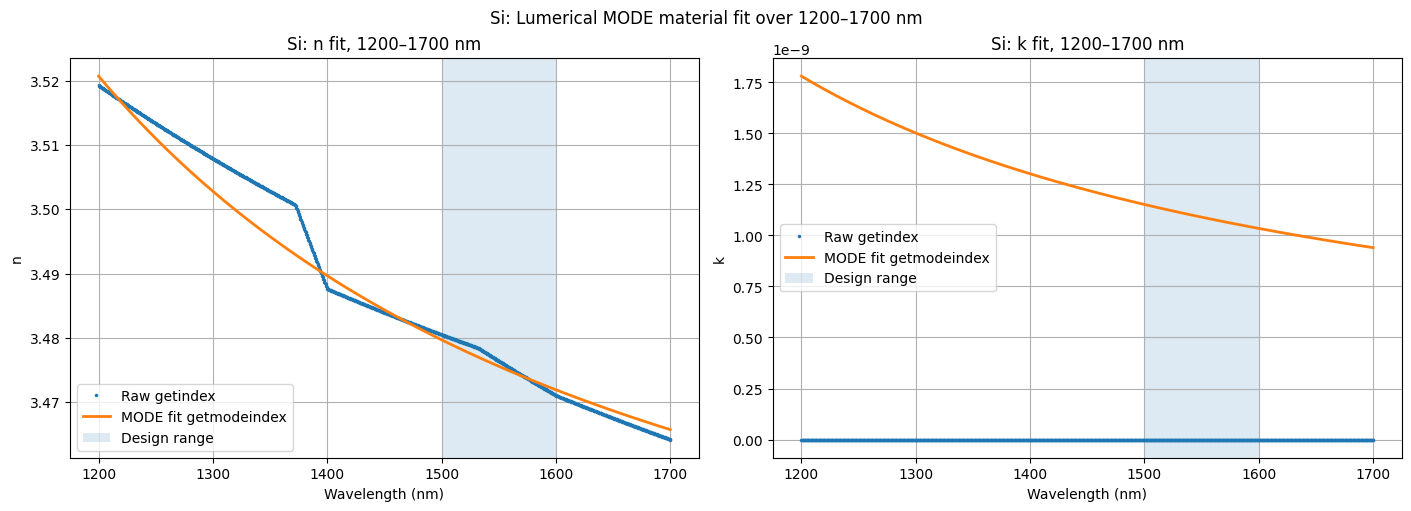

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_MODE_fit_1200_1700nm.png


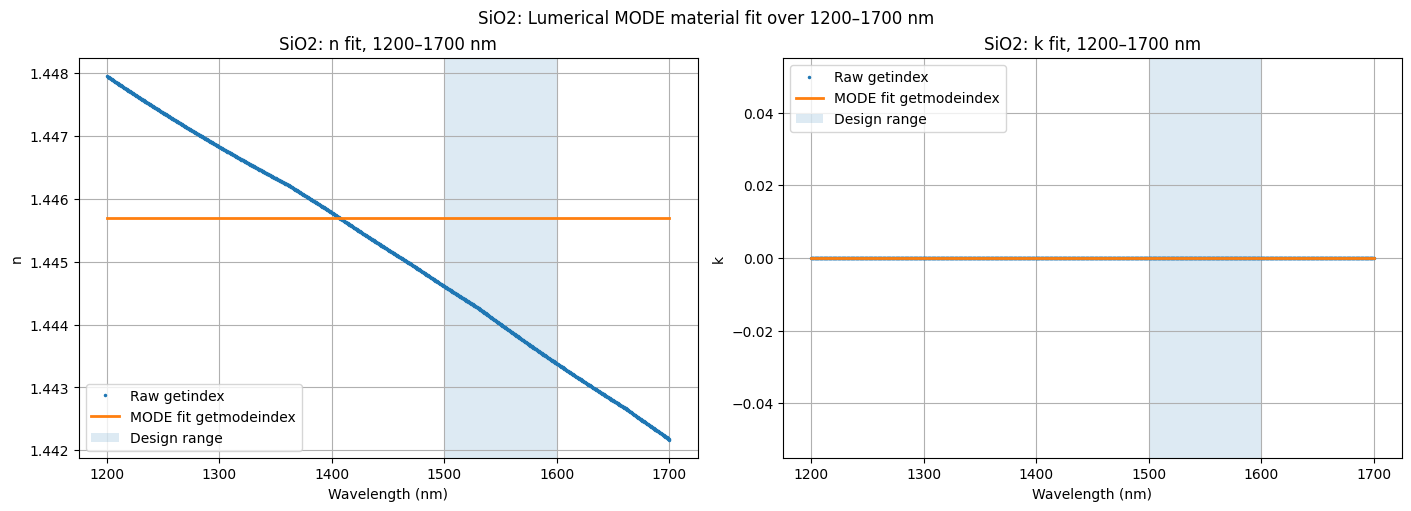

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_MODE_fit_1200_1700nm.png


In [7]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[0].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[0].set_title(f"{label}: n fit, 1200–1700 nm")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[1].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[1].set_title(f"{label}: k fit, 1200–1700 nm")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    fig.suptitle(
        f"{label}: Lumerical MODE material fit over 1200–1700 nm"
    )

    plot_path = material_dir / f"{label}_MODE_fit_1200_1700nm.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Plot fitted material only in 1500–1600 nm

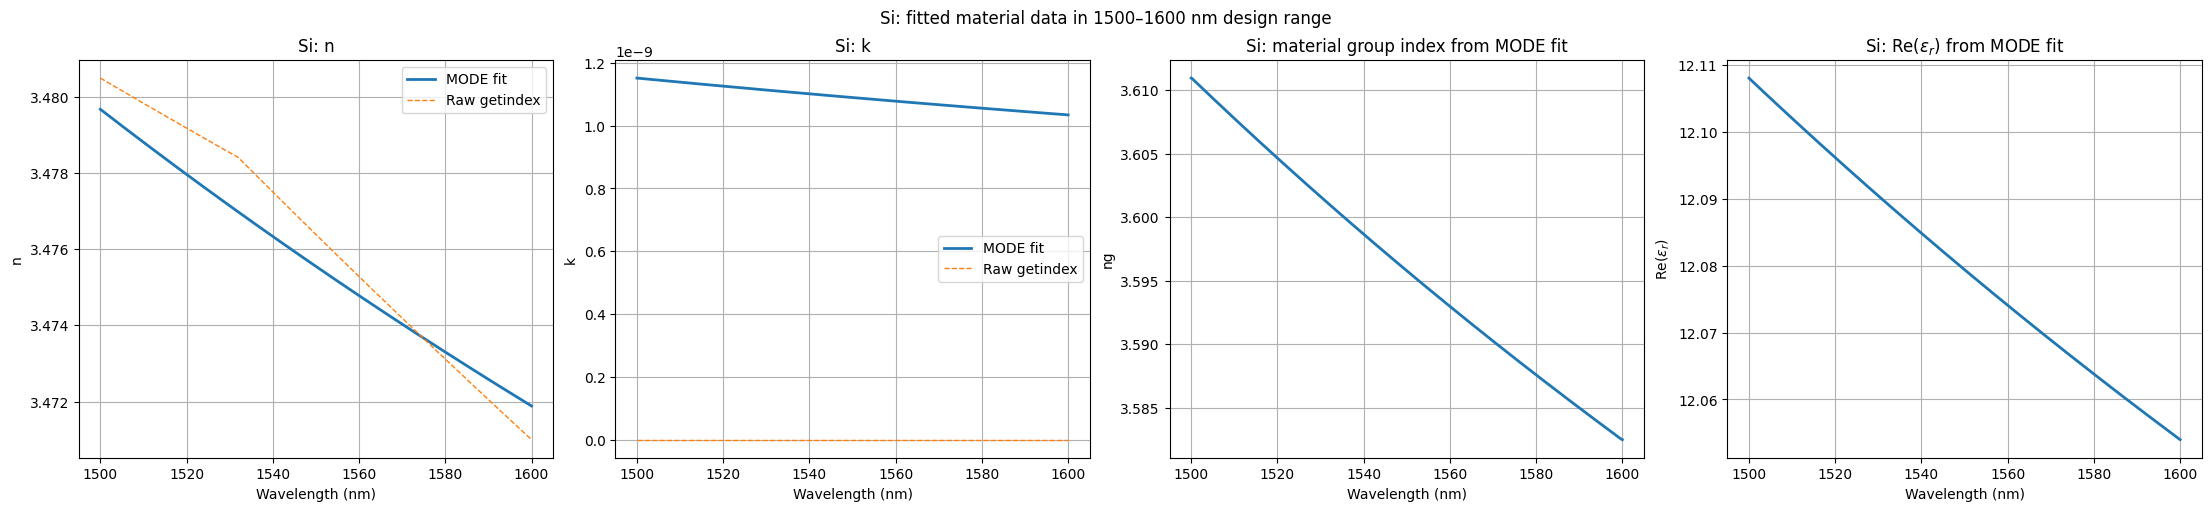

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_MODE_fit_design_range_1500_1600nm.png


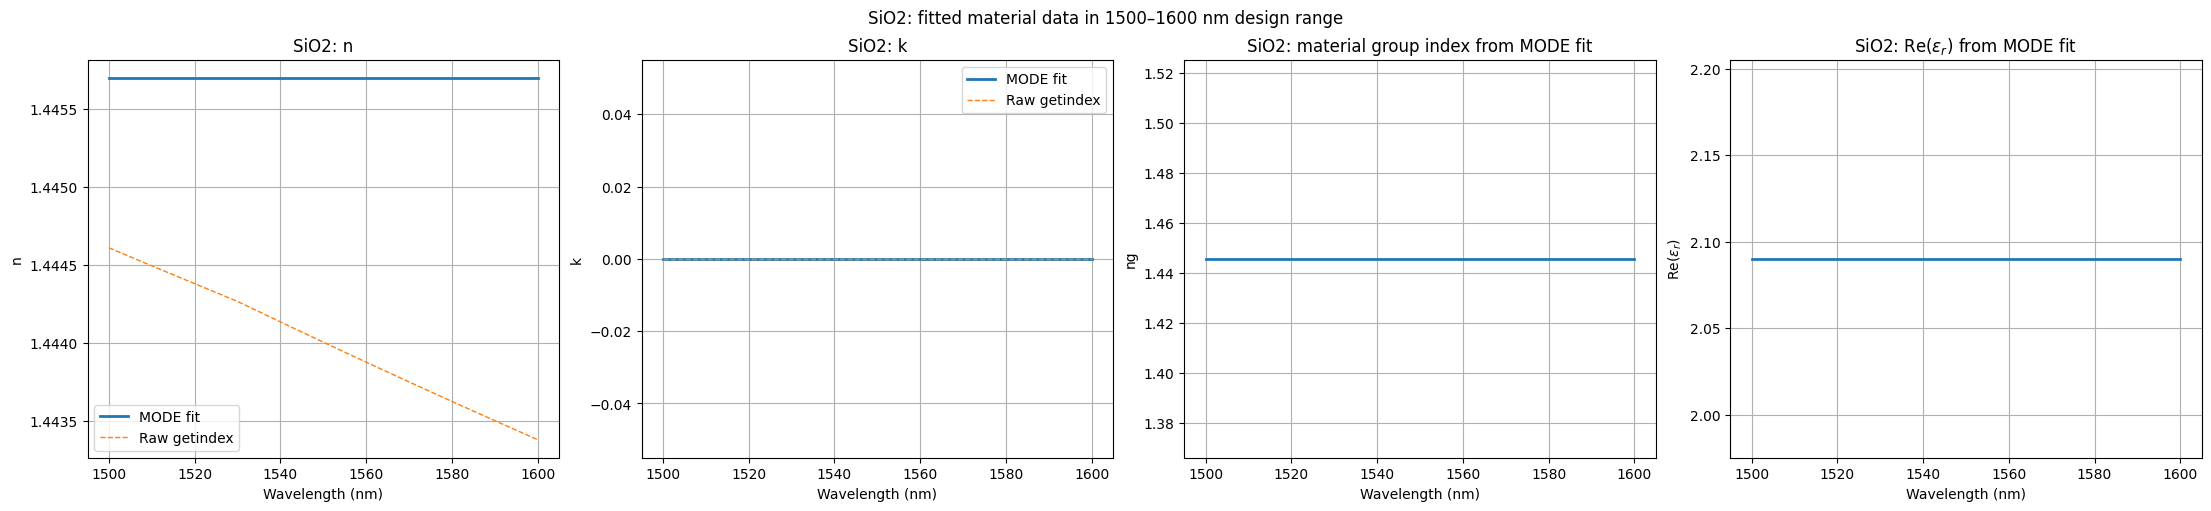

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_MODE_fit_design_range_1500_1600nm.png


In [8]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

    axs[0].plot(d["lambda_nm"], d["n"], linewidth=2, label="MODE fit")
    axs[0].plot(d["lambda_nm"], d["n_raw"], "--", linewidth=1, label="Raw getindex")
    axs[0].set_title(f"{label}: n")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(d["lambda_nm"], d["k"], linewidth=2, label="MODE fit")
    axs[1].plot(d["lambda_nm"], d["k_raw"], "--", linewidth=1, label="Raw getindex")
    axs[1].set_title(f"{label}: k")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(d["lambda_nm"], d["ng"], linewidth=2)
    axs[2].set_title(f"{label}: material group index from MODE fit")
    axs[2].set_xlabel("Wavelength (nm)")
    axs[2].set_ylabel("ng")
    axs[2].grid(True)

    axs[3].plot(d["lambda_nm"], d["eps_real"], linewidth=2)
    axs[3].set_title(f"{label}: Re($\\epsilon_r$) from MODE fit")
    axs[3].set_xlabel("Wavelength (nm)")
    axs[3].set_ylabel(r"Re($\epsilon_r$)")
    axs[3].grid(True)

    fig.suptitle(
        f"{label}: fitted material data in 1500–1600 nm design range"
    )

    plot_path = material_dir / f"{label}_MODE_fit_design_range_1500_1600nm.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Print material values at 1550 nm

In [9]:
lambda0_nm = settings["wavelength_um"] * 1000.0

material_at_lambda0 = {}

for label, d in material_data.items():

    n0 = np.interp(lambda0_nm, d["lambda_nm"], d["n"])
    k0 = np.interp(lambda0_nm, d["lambda_nm"], d["k"])
    ng0 = np.interp(lambda0_nm, d["lambda_nm"], d["ng"])
    eps_energy0 = np.interp(lambda0_nm, d["lambda_nm"], d["eps_energy"])

    material_at_lambda0[label] = {
        "n": n0,
        "k": k0,
        "ng": ng0,
        "eps_energy": eps_energy0,
    }

print(f"Material values at lambda = {lambda0_nm:.1f} nm")
print("Values are from MODE multi-coefficient fit over 1200–1700 nm.\n")

for label, d in material_at_lambda0.items():
    print(
        f"{label}: "
        f"n = {d['n']:.8f}, "
        f"k = {d['k']:.3e}, "
        f"ng_material = {d['ng']:.8f}, "
        f"eps_energy = {d['eps_energy']:.8f}"
    )

Material values at lambda = 1550.0 nm
Values are from MODE multi-coefficient fit over 1200–1700 nm.

Si: n = 3.47554455, k = 1.090e-09, ng_material = 3.59578939, eps_energy = 12.91524254
SiO2: n = 1.44569554, k = 0.000e+00, ng_material = 1.44569554, eps_energy = 2.09003561


## Clear layout and add SiO₂ box

In [10]:
mode.switchtolayout()
mode.deleteall()

# ------------------------------------------------------------------
# SiO2 simulation box
# ------------------------------------------------------------------
mode.addrect()
mode.set("name", "SiO2_box")
mode.set("material", settings["sio2_material_name"])

mode.set("x", 0.0)
mode.set("y", 0.0)
mode.set("z", 0.0)

mode.set("x span", settings["oxide_x_span_um"] * um)
mode.set("y span", settings["oxide_y_span_um"] * um)
mode.set("z span", settings["z_span_um"] * um)

# ------------------------------------------------------------------
# Left Si waveguide
# ------------------------------------------------------------------
mode.addrect()
mode.set("name", "Si_waveguide_left")
mode.set("material", settings["si_material_name"])

mode.set("x", settings["left_wg_center_x_um"] * um)
mode.set("y", settings["wg_center_y_um"] * um)
mode.set("z", 0.0)

mode.set("x span", settings["wg_width_um"] * um)
mode.set("y span", settings["wg_thickness_um"] * um)
mode.set("z span", settings["z_span_um"] * um)

# ------------------------------------------------------------------
# Right Si waveguide
# ------------------------------------------------------------------
mode.addrect()
mode.set("name", "Si_waveguide_right")
mode.set("material", settings["si_material_name"])

mode.set("x", settings["right_wg_center_x_um"] * um)
mode.set("y", settings["wg_center_y_um"] * um)
mode.set("z", 0.0)

mode.set("x span", settings["wg_width_um"] * um)
mode.set("y span", settings["wg_thickness_um"] * um)
mode.set("z span", settings["z_span_um"] * um)

print("Added SiO2 box and two symmetric silicon waveguides.")
print(f"Left center x  = {settings['left_wg_center_x_um']:.4f} um")
print(f"Right center x = {settings['right_wg_center_x_um']:.4f} um")
print(f"Gap            = {settings['gap_um']:.4f} um")
print(f"Width          = {settings['wg_width_um']:.4f} um")
print(f"Thickness      = {settings['wg_thickness_um']:.4f} um")

Added SiO2 box and two symmetric silicon waveguides.
Left center x  = -0.3250 um
Right center x = 0.3250 um
Gap            = 0.1500 um
Width          = 0.5000 um
Thickness      = 0.2200 um


## Add FDE region

In [11]:
mode.addfde()

# Propagation along z, cross-section in x-y
mode.set("solver type", "2D Z normal")

# Full FDE centered at x = 0, y = 0
mode.set("x", settings["fde_center_x_um"] * um)
mode.set("y", settings["fde_center_y_um"] * um)

mode.set("x span", settings["fde_x_span_um"] * um)
mode.set("y span", settings["fde_y_span_um"] * um)

mode.set("wavelength", settings["wavelength_um"] * um)

# Boundary conditions: full-domain solve, no symmetry BC
bc = settings["fde_bc"]

mode.set("x min bc", bc)
mode.set("x max bc", bc)
mode.set("y min bc", bc)
mode.set("y max bc", bc)

# Number of modes
mode.set("number of trial modes", settings["number_of_trial_modes"])

# Mesh
mode.set("define x mesh by", "maximum mesh step")
mode.set("define y mesh by", "maximum mesh step")

mode.set("dx", settings["fde_dx_um"] * um)
mode.set("dy", settings["fde_dy_um"] * um)

print("Added full FDE region.")
print(f"FDE center = ({settings['fde_center_x_um']}, {settings['fde_center_y_um']}) um")
print(f"FDE span   = {settings['fde_x_span_um']} um x {settings['fde_y_span_um']} um")
print(f"BC         = {bc} on all boundaries")
print(f"Global dx  = {settings['fde_dx_um']} um")
print(f"Global dy  = {settings['fde_dy_um']} um")

Added full FDE region.
FDE center = (0.0, 0.0) um
FDE span   = 15.0 um x 15.0 um
BC         = PML on all boundaries
Global dx  = 0.05 um
Global dy  = 0.05 um


## Optional extra mesh

In [12]:
if settings["use_extra_mesh"]:

    # Mesh contains both waveguides and the full gap.
    mesh_x_span_um = (
        settings["coupler_total_width_um"]
        + 2.0 * settings["mesh_x_margin_um"]
    )

    mesh_y_span_um = (
        settings["wg_thickness_um"]
        + 2.0 * settings["mesh_y_margin_um"]
    )

    mode.addmesh()
    mode.set("name", settings["extra_mesh_name"])

    # Coupler is symmetric around x = 0 and y = 0
    mode.set("x", 0.0)
    mode.set("y", settings["wg_center_y_um"] * um)
    mode.set("z", 0.0)

    mode.set("x span", mesh_x_span_um * um)
    mode.set("y span", mesh_y_span_um * um)
    mode.set("z span", settings["z_span_um"] * um)

    mode.set("override x mesh", 1)
    mode.set("override y mesh", 1)

    mode.set("dx", settings["local_dx_um"] * um)
    mode.set("dy", settings["local_dy_um"] * um)

    print("Added extra mesh override around both waveguides.")
    print(f"Mesh center x = 0.0000 um")
    print(f"Mesh center y = {settings['wg_center_y_um']:.4f} um")
    print(f"Mesh x span   = {mesh_x_span_um:.4f} um")
    print(f"Mesh y span   = {mesh_y_span_um:.4f} um")
    print(f"Local dx      = {settings['local_dx_um']} um")
    print(f"Local dy      = {settings['local_dy_um']} um")

else:
    print("Extra mesh override disabled.")

Added extra mesh override around both waveguides.
Mesh center x = 0.0000 um
Mesh center y = 0.0000 um
Mesh x span   = 1.7500 um
Mesh y span   = 0.8200 um
Local dx      = 0.01 um
Local dy      = 0.01 um


## Create run folder and save simulation

In [13]:
project_root = Path.cwd()

simulation_runs_dir = project_root / "simulation_runs"
simulation_runs_dir.mkdir(exist_ok=True)

base_run_name = settings["folder_name"]

existing_run_numbers = []

for item in simulation_runs_dir.iterdir():
    if item.is_dir():
        m = re.fullmatch(rf"{re.escape(base_run_name)}_(\d+)", item.name)
        if m:
            existing_run_numbers.append(int(m.group(1)))

next_run_number = 1 if not existing_run_numbers else max(existing_run_numbers) + 1

run_folder_name = f"{base_run_name}_{next_run_number:02d}"
run_dir = simulation_runs_dir / run_folder_name
run_dir.mkdir(exist_ok=False)

lms_file_path = run_dir / f"{settings['simulation_file_name']}.lms"

mode.save(str(lms_file_path))

print("Created run folder:")
print(run_dir)

print("\nSaved simulation:")
print(lms_file_path)


# ------------------------------------------------------------------
# Solve modes
# ------------------------------------------------------------------
mode.findmodes()

print("\nFDE supermode solve finished.")


# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def squeeze_arr(a):
    return np.squeeze(np.array(a))


def scalar_or_nan(x):
    try:
        x = np.squeeze(np.array(x))
        if x.size == 0:
            return np.nan
        return np.real(x.item())
    except Exception:
        return np.nan


def get_from_mode_or_list(mode_obj, mode_number, key, default=np.nan):
    try:
        return mode_obj.getdata(f"FDE::data::mode{mode_number}", key)
    except Exception:
        pass

    try:
        return mode_obj.getdata("FDE::data", key)[mode_number - 1]
    except Exception:
        return default


# ------------------------------------------------------------------
# Extract raw mode table
# ------------------------------------------------------------------
num_modes = int(settings["number_of_trial_modes"])

mode_rows = []

for m in range(1, num_modes + 1):

    neff = get_from_mode_or_list(mode, m, "neff")

    if np.all(pd.isna(neff)):
        continue

    loss = get_from_mode_or_list(mode, m, "loss")
    ng = get_from_mode_or_list(mode, m, "ng")

    te_pol = get_from_mode_or_list(mode, m, "TE polarization fraction")
    wg_te_fraction = get_from_mode_or_list(mode, m, "waveguide TE fraction")
    wg_te_tm = get_from_mode_or_list(mode, m, "waveguide TE/TM fraction")

    mode_rows.append({
        "mode_number": m,
        "neff": complex(np.squeeze(neff)),
        "neff_real": np.real(np.squeeze(neff)),
        "neff_imag": np.imag(np.squeeze(neff)),
        "loss_dB_per_cm": scalar_or_nan(loss),
        "group_index": complex(np.squeeze(ng)) if not np.all(pd.isna(ng)) else np.nan,
        "group_index_real": np.real(np.squeeze(ng)) if not np.all(pd.isna(ng)) else np.nan,
        "TE_polarization_fraction": scalar_or_nan(te_pol),
        "waveguide_TE_fraction": scalar_or_nan(wg_te_fraction),
        "waveguide_TE_TM_fraction": scalar_or_nan(wg_te_tm),
    })

modes_df = pd.DataFrame(mode_rows)

raw_modes_path = run_dir / "raw_supermodes.csv"
modes_df.to_csv(raw_modes_path, index=False)

print("\nSaved raw supermode table:")
print(raw_modes_path)


# ------------------------------------------------------------------
# Select first two TE-like modes
# ------------------------------------------------------------------
te_modes_df = modes_df[
    modes_df["TE_polarization_fraction"] >= settings["te_fraction_min"]
].copy()

if len(te_modes_df) < 2:
    raise RuntimeError(
        "Less than two TE-like modes found. "
        "Increase number_of_trial_modes or lower te_fraction_min."
    )

# Sort by real neff.
# For identical symmetric waveguides, the two highest-neff TE-like modes
# are the coupled even/odd supermodes.
te_modes_df = te_modes_df.sort_values(
    "neff_real",
    ascending=False,
).reset_index(drop=True)

mode_high = te_modes_df.iloc[0].to_dict()
mode_low = te_modes_df.iloc[1].to_dict()

# Usually for two identical coupled strip waveguides:
# the even supermode has slightly higher neff than the odd supermode.
# But we still store both explicitly.
n_even = float(mode_high["neff_real"])
n_odd = float(mode_low["neff_real"])

delta_n = abs(n_even - n_odd)

if delta_n <= 0:
    raise RuntimeError("delta_n is zero or negative. Could not calculate coupling length.")

lambda_um = settings["wavelength_um"]

# ------------------------------------------------------------------
# Correct coupling length formulas
# ------------------------------------------------------------------
# Full power transfer length:
# L_full_power = lambda / [2 |n_even - n_odd|]
#
# 50/50 coupling length:
# L_50_50 = L_full_power / 2
#        = lambda / [4 |n_even - n_odd|]
# ------------------------------------------------------------------
L_full_power_um = lambda_um / (2.0 * delta_n)
L_50_50_um = 0.5 * L_full_power_um

supermode_result = {
    "wavelength_um": lambda_um,
    "wg_width_um": settings["wg_width_um"],
    "wg_thickness_um": settings["wg_thickness_um"],
    "gap_um": settings["gap_um"],

    "n_even_assumed": n_even,
    "n_odd_assumed": n_odd,
    "delta_n": delta_n,

    "L_full_power_um": L_full_power_um,
    "L_full_power_mm": L_full_power_um / 1000.0,

    "L_50_50_um": L_50_50_um,
    "L_50_50_mm": L_50_50_um / 1000.0,

    "even_assumed_mode_number": int(mode_high["mode_number"]),
    "odd_assumed_mode_number": int(mode_low["mode_number"]),

    "even_assumed_TE_polarization_fraction": mode_high["TE_polarization_fraction"],
    "odd_assumed_TE_polarization_fraction": mode_low["TE_polarization_fraction"],

    "even_assumed_group_index_real": mode_high["group_index_real"],
    "odd_assumed_group_index_real": mode_low["group_index_real"],

    "even_assumed_loss_dB_per_cm": mode_high["loss_dB_per_cm"],
    "odd_assumed_loss_dB_per_cm": mode_low["loss_dB_per_cm"],
}

supermode_df = pd.DataFrame([supermode_result])

supermode_result_path = run_dir / "supermode_coupling_result.csv"
supermode_df.to_csv(supermode_result_path, index=False)

mode.save(str(lms_file_path))

print()
print("=" * 80)
print("DOUBLE-WAVEGUIDE SUPERMODE RESULT")
print("=" * 80)
print(f"gap                       = {settings['gap_um']:.4f} um")
print(f"n_even assumed             = {n_even:.10f}")
print(f"n_odd assumed              = {n_odd:.10f}")
print(f"delta_n                   = {delta_n:.10e}")
print()
print(f"L_full_power              = {L_full_power_um:.4f} um = {L_full_power_um / 1000.0:.6f} mm")
print(f"L_50_50                   = {L_50_50_um:.4f} um = {L_50_50_um / 1000.0:.6f} mm")
print()
print(f"Even assumed mode number  = {int(mode_high['mode_number'])}")
print(f"Odd assumed mode number   = {int(mode_low['mode_number'])}")
print()
print("Saved:")
print(raw_modes_path)
print(supermode_result_path)
print(lms_file_path)

supermode_df

Created run folder:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08

Saved simulation:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\double_si_wg_supermode_fde.lms

FDE supermode solve finished.

Saved raw supermode table:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\raw_supermodes.csv

DOUBLE-WAVEGUIDE SUPERMODE RESULT
gap                       = 0.1500 um
n_even assumed             = 2.4645660756
n_odd assumed              = 2.4320782972
delta_n                   = 3.2487778397e-02

L_full_power              = 23.8551 um = 0.023855 mm
L_50_50                   = 11.9276 um = 0.011928 mm

Even assumed mode number  = 1
Odd assumed mode number   = 2

Saved:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\

,wavelength_um,wg_width_um,wg_thickness_um,gap_um,n_even_assumed,n_odd_assumed,delta_n,L_full_power_um,L_full_power_mm,L_50_50_um,L_50_50_mm,even_assumed_mode_number,odd_assumed_mode_number,even_assumed_TE_polarization_fraction,odd_assumed_TE_polarization_fraction,even_assumed_group_index_real,odd_assumed_group_index_real,even_assumed_loss_dB_per_cm,odd_assumed_loss_dB_per_cm
0,1.55,0.5,0.22,0.15,2.464566,2.432078,0.032488,23.855125,0.023855,11.927562,0.011928,1,2,0.983702,0.985576,4.120649139782062,4.315759607704647,3.834960e-10,-1.998952e-09


## Selected TE modes table

In [14]:
selected_modes_df = pd.DataFrame([
    {
        "label": "even_like_assumed",
        "mode_number": int(mode_high["mode_number"]),
        "neff_real": mode_high["neff_real"],
        "TE_polarization_fraction": mode_high["TE_polarization_fraction"],
        "waveguide_TE_fraction": mode_high["waveguide_TE_fraction"],
        "group_index_real": mode_high["group_index_real"],
        "loss_dB_per_cm": mode_high["loss_dB_per_cm"],
    },
    {
        "label": "odd_like_assumed",
        "mode_number": int(mode_low["mode_number"]),
        "neff_real": mode_low["neff_real"],
        "TE_polarization_fraction": mode_low["TE_polarization_fraction"],
        "waveguide_TE_fraction": mode_low["waveguide_TE_fraction"],
        "group_index_real": mode_low["group_index_real"],
        "loss_dB_per_cm": mode_low["loss_dB_per_cm"],
    },
])

selected_modes_path = run_dir / "selected_TE_supermodes.csv"
selected_modes_df.to_csv(selected_modes_path, index=False)

print("Saved selected TE supermodes:")
print(selected_modes_path)

selected_modes_df

Saved selected TE supermodes:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\selected_TE_supermodes.csv


,label,mode_number,neff_real,TE_polarization_fraction,waveguide_TE_fraction,group_index_real,loss_dB_per_cm
0,even_like_assumed,1,2.464566075635981,0.983702,NaN,4.120649139782062,3.834960e-10
1,odd_like_assumed,2,2.4320782972388253,0.985576,NaN,4.315759607704647,-1.998952e-09


## Plot directories and field helper functions

In [15]:
plot_dir = run_dir / "plots"
plot_dir.mkdir(exist_ok=True)

field_dir = run_dir / "fields"
field_dir.mkdir(exist_ok=True)

results_dir = run_dir


def squeeze_arr(a):
    return np.squeeze(np.array(a))


def real_arr(a):
    return np.real(squeeze_arr(a))


def get_mode_data(mode_obj, mode_number, quantity):
    return squeeze_arr(mode_obj.getdata(f"FDE::data::mode{mode_number}", quantity))


def safe_get_mode_data(mode_obj, mode_number, quantity, default=np.nan):
    try:
        return get_mode_data(mode_obj, mode_number, quantity)
    except Exception:
        return default


def get_index_map_from_material(mode_obj):
    try:
        n = mode_obj.getdata("FDE::data::material", "index")
        return np.squeeze(np.real(np.array(n)))
    except Exception:
        pass

    try:
        nx = mode_obj.getdata("FDE::data::material", "index_x")
        return np.squeeze(np.real(np.array(nx)))
    except Exception:
        pass

    raise RuntimeError("Could not find index data in FDE::data::material.")


def nearest_index(arr, value):
    return int(np.argmin(np.abs(arr - value)))


def apply_window(x, y, data, x_window=None, y_window=None):
    x_mask = np.ones_like(x, dtype=bool)
    y_mask = np.ones_like(y, dtype=bool)

    if x_window is not None:
        x_mask = (x >= x_window[0]) & (x <= x_window[1])

    if y_window is not None:
        y_mask = (y >= y_window[0]) & (y <= y_window[1])

    return x[x_mask], y[y_mask], data[np.ix_(x_mask, y_mask)]


def get_supermode_fields(mode_number):
    x = real_arr(get_mode_data(mode, mode_number, "x")) / um
    y = real_arr(get_mode_data(mode, mode_number, "y")) / um

    Ex = np.squeeze(get_mode_data(mode, mode_number, "Ex"))
    Ey = np.squeeze(get_mode_data(mode, mode_number, "Ey"))
    Ez = np.squeeze(get_mode_data(mode, mode_number, "Ez"))

    Hx = np.squeeze(get_mode_data(mode, mode_number, "Hx"))
    Hy = np.squeeze(get_mode_data(mode, mode_number, "Hy"))
    Hz = np.squeeze(get_mode_data(mode, mode_number, "Hz"))

    n = np.squeeze(get_index_map_from_material(mode))

    if n.ndim == 3:
        n_plot = n[:, :, 0]
    elif n.ndim == 2:
        n_plot = n
    else:
        raise ValueError(f"Unexpected index map shape: {n.shape}")

    E2 = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    H2 = np.abs(Hx)**2 + np.abs(Hy)**2 + np.abs(Hz)**2

    Sz = 0.5 * np.real(Ex * np.conj(Hy) - Ey * np.conj(Hx))

    return {
        "x": x,
        "y": y,
        "Ex": Ex,
        "Ey": Ey,
        "Ez": Ez,
        "Hx": Hx,
        "Hy": Hy,
        "Hz": Hz,
        "E2": E2,
        "H2": H2,
        "Sz": Sz,
        "n": n_plot,
    }


def save_supermode_field_csv(mode_number, mode_label):
    d = get_supermode_fields(mode_number)

    x = d["x"]
    y = d["y"]

    X, Y = np.meshgrid(x, y, indexing="ij")

    field_df = pd.DataFrame({
        "x_um": X.ravel(),
        "y_um": Y.ravel(),

        "Ex_real": np.real(d["Ex"]).ravel(),
        "Ex_imag": np.imag(d["Ex"]).ravel(),
        "Ey_real": np.real(d["Ey"]).ravel(),
        "Ey_imag": np.imag(d["Ey"]).ravel(),
        "Ez_real": np.real(d["Ez"]).ravel(),
        "Ez_imag": np.imag(d["Ez"]).ravel(),

        "Hx_real": np.real(d["Hx"]).ravel(),
        "Hx_imag": np.imag(d["Hx"]).ravel(),
        "Hy_real": np.real(d["Hy"]).ravel(),
        "Hy_imag": np.imag(d["Hy"]).ravel(),
        "Hz_real": np.real(d["Hz"]).ravel(),
        "Hz_imag": np.imag(d["Hz"]).ravel(),

        "E2_abs": d["E2"].ravel(),
        "H2_abs": d["H2"].ravel(),
        "Sz_real": d["Sz"].ravel(),
        "index": d["n"].ravel(),
    })

    csv_path = field_dir / f"{mode_label}_mode_{mode_number}_fields.csv"
    field_df.to_csv(csv_path, index=False)

    print("Saved field CSV:", csv_path)

    return csv_path


even_mode_number = int(mode_high["mode_number"])
odd_mode_number = int(mode_low["mode_number"])

modes_to_plot = [
    (even_mode_number, "even_like"),
    (odd_mode_number, "odd_like"),
]

for mode_number, mode_label in modes_to_plot:
    save_supermode_field_csv(mode_number, mode_label)

Saved field CSV: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\fields\even_like_mode_1_fields.csv
Saved field CSV: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\fields\odd_like_mode_2_fields.csv


## Plot full E/H fields like attached notebook

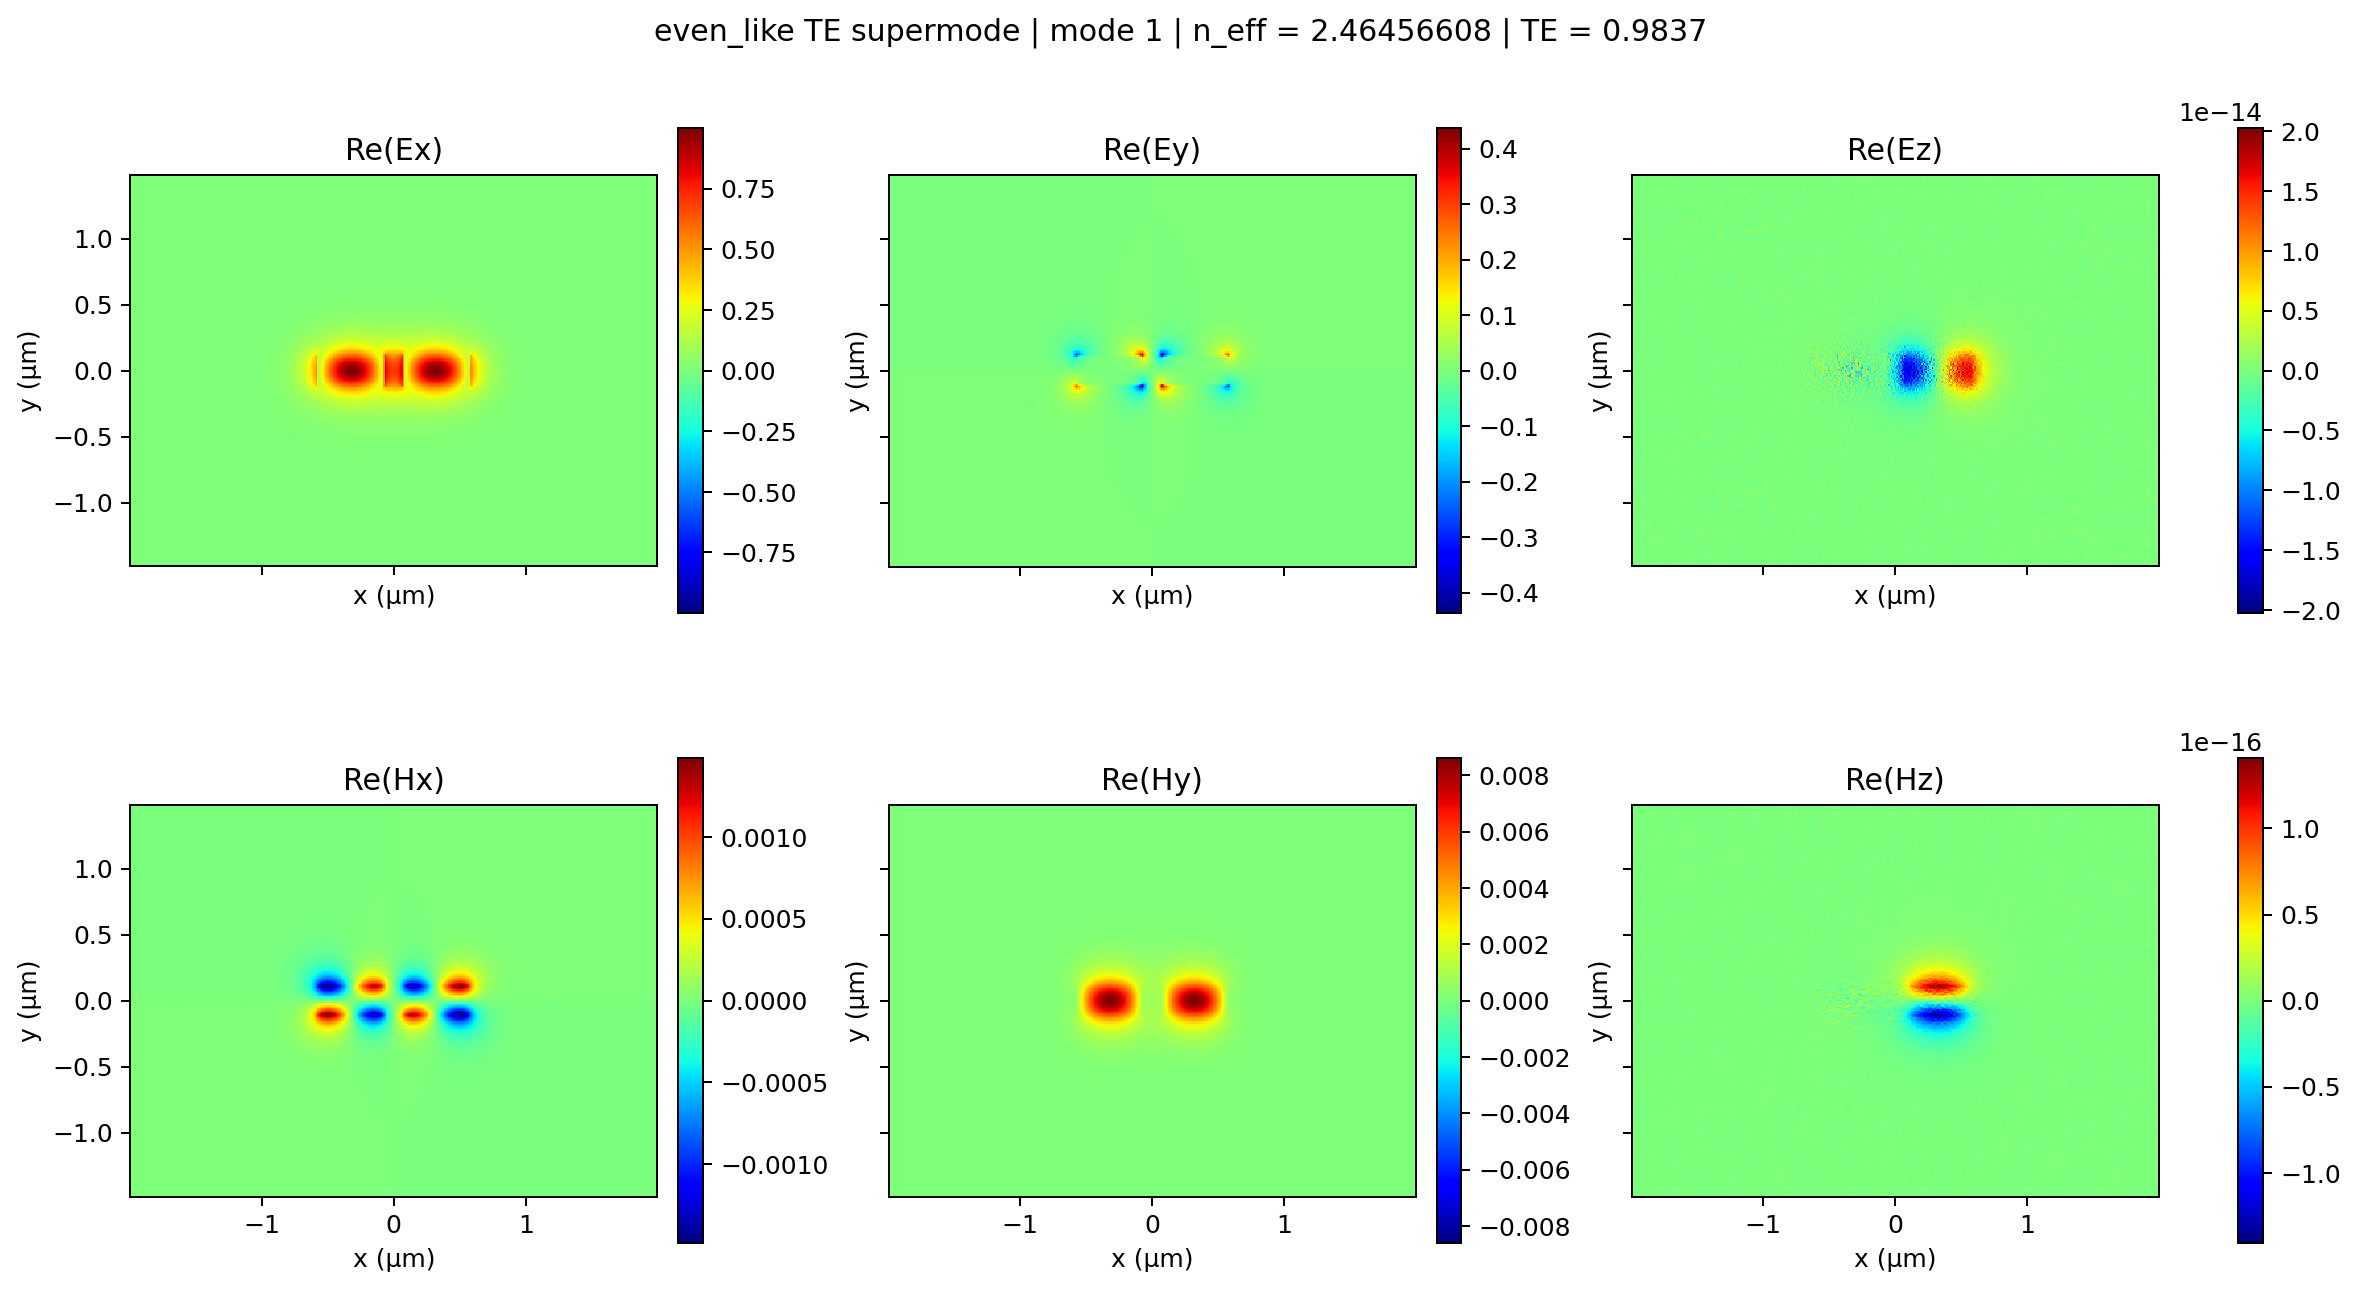

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\fields_even_like_TE_mode_1_windowed.png


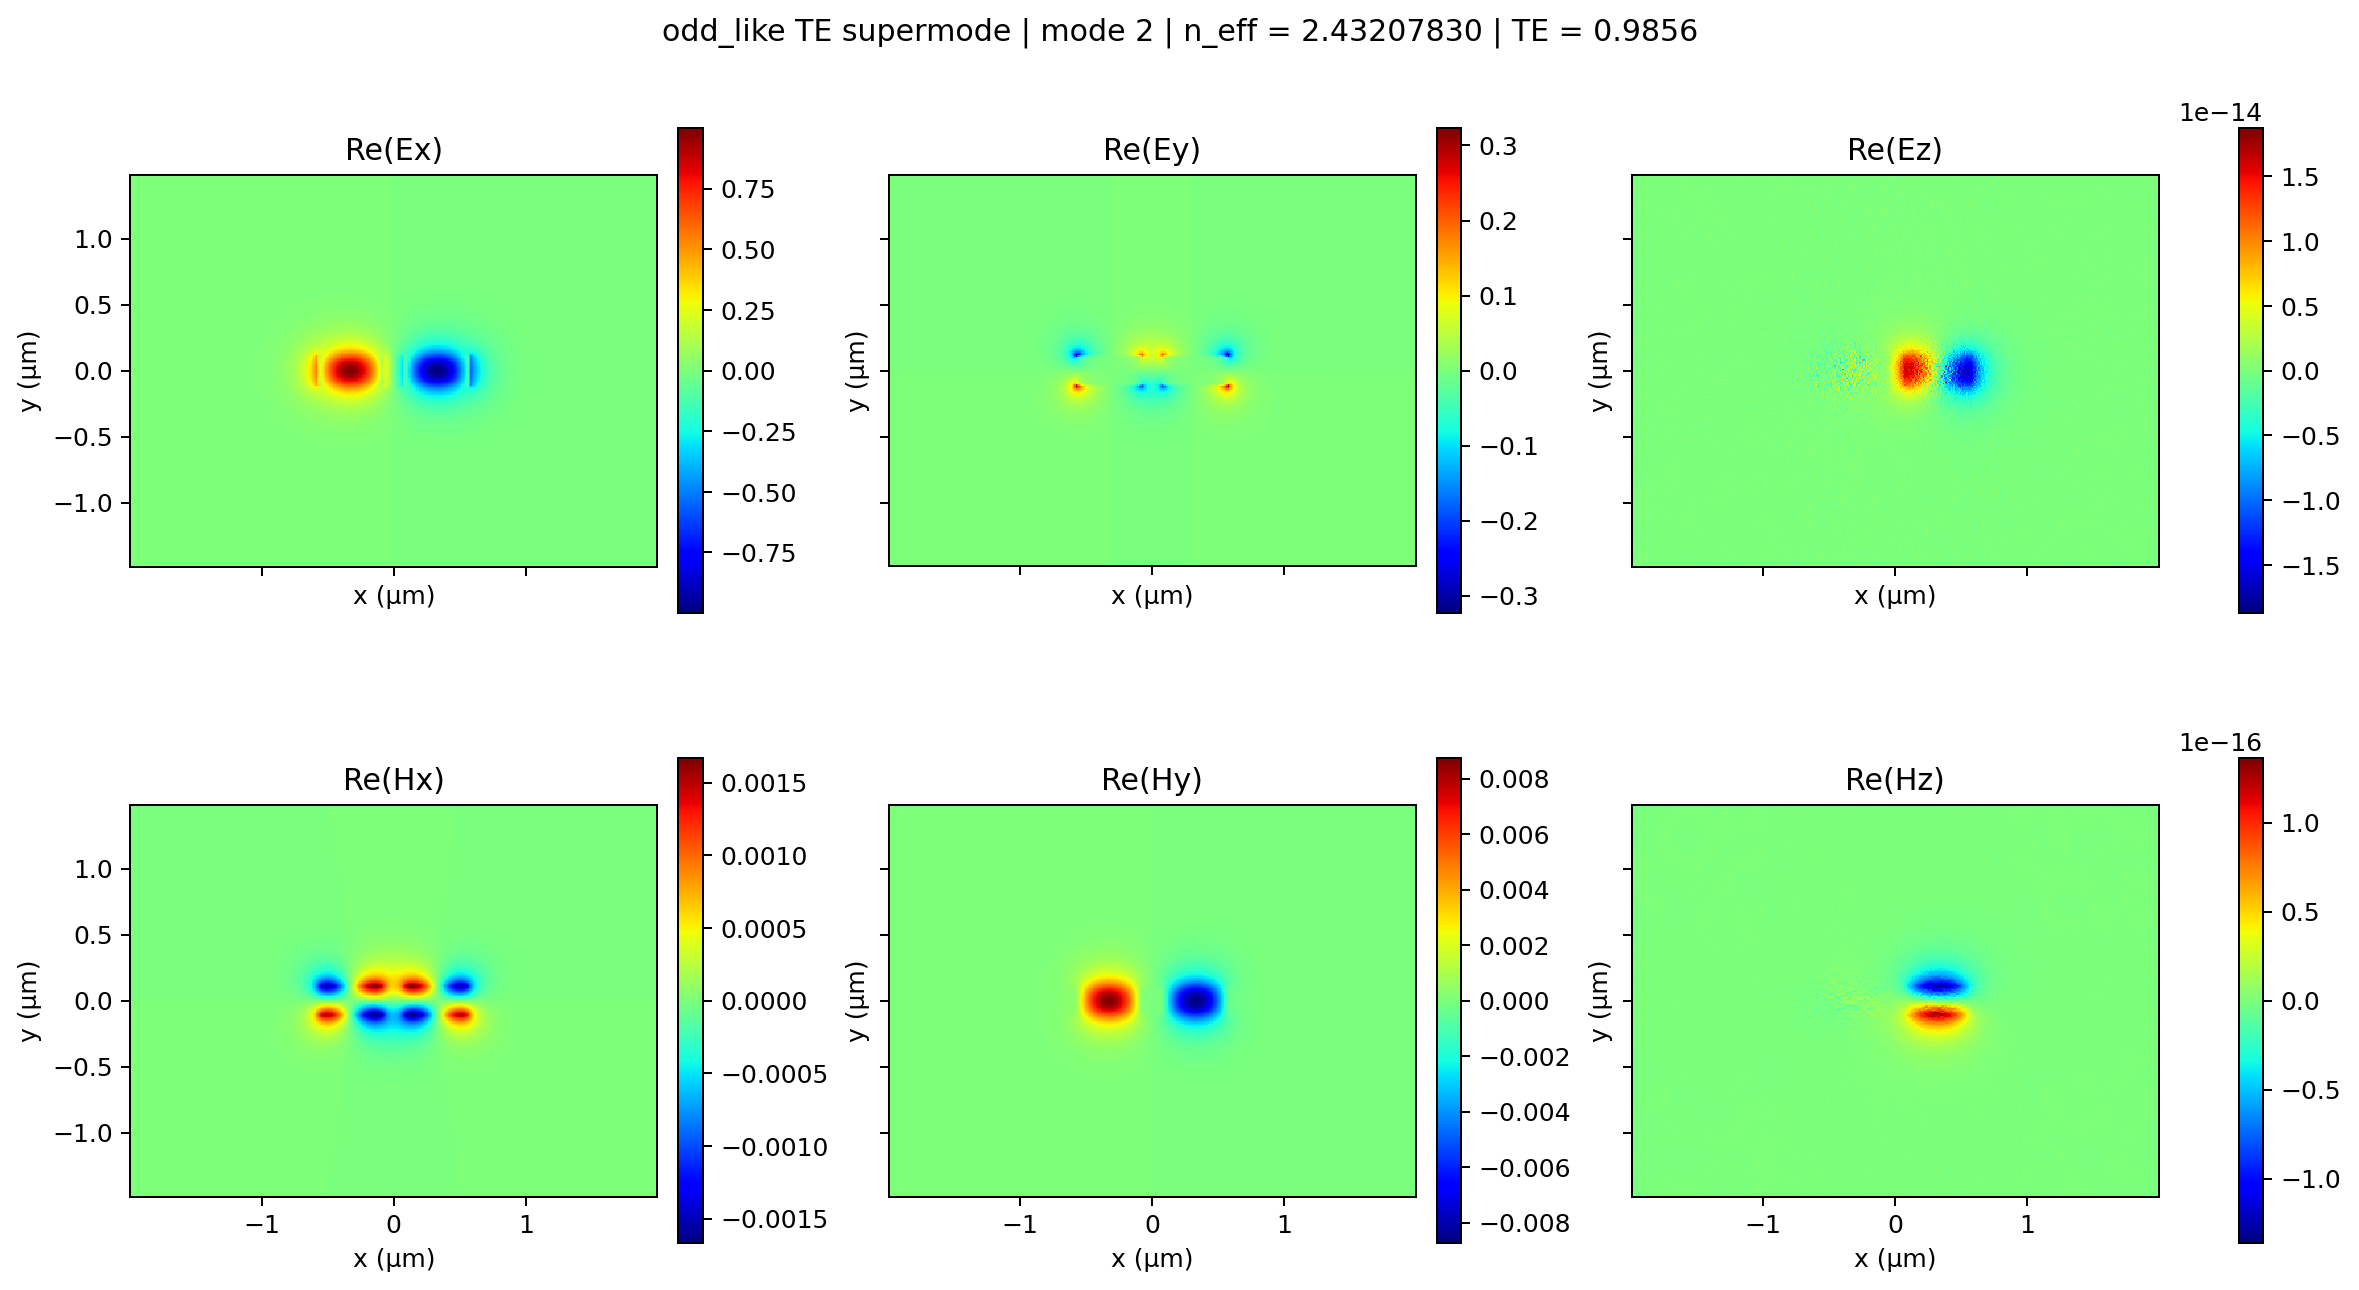

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\fields_odd_like_TE_mode_2_windowed.png


In [16]:
def plot_TE_supermode_fields(mode_number, mode_label):
    d = get_supermode_fields(mode_number)

    x = d["x"]
    y = d["y"]

    x_window = settings["plot_window_x_um"]
    y_window = settings["plot_window_y_um"]

    fields = [
        np.real(d["Ex"]),
        np.real(d["Ey"]),
        np.real(d["Ez"]),
        np.real(d["Hx"]),
        np.real(d["Hy"]),
        np.real(d["Hz"]),
    ]

    titles = [
        "Re(Ex)",
        "Re(Ey)",
        "Re(Ez)",
        "Re(Hx)",
        "Re(Hy)",
        "Re(Hz)",
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(13, 7),
        dpi=180,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, field, title in zip(axes.flat, fields, titles):
        x_win, y_win, field_win = apply_window(
            x,
            y,
            field,
            x_window,
            y_window,
        )

        vmax = np.nanmax(np.abs(field_win))

        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        im = ax.pcolormesh(
            x_win,
            y_win,
            field_win.T,
            shading="auto",
            cmap=settings["cmap"],
            vmin=-vmax,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("x (µm)")
        ax.set_ylabel("y (µm)")
        ax.set_aspect("equal")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    neff_here = modes_df.loc[
        modes_df["mode_number"].astype(int) == int(mode_number),
        "neff_real",
    ].values[0]

    te_here = modes_df.loc[
        modes_df["mode_number"].astype(int) == int(mode_number),
        "TE_polarization_fraction",
    ].values[0]

    fig.suptitle(
        f"{mode_label} TE supermode | mode {mode_number} | "
        f"n_eff = {neff_here:.8f} | TE = {te_here:.4f}",
        y=1.03,
    )

    save_path = plot_dir / f"fields_{mode_label}_TE_mode_{mode_number}_windowed.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


for mode_number, mode_label in modes_to_plot:
    plot_TE_supermode_fields(mode_number, mode_label)

## Plot index, E², Sz for even/odd modes

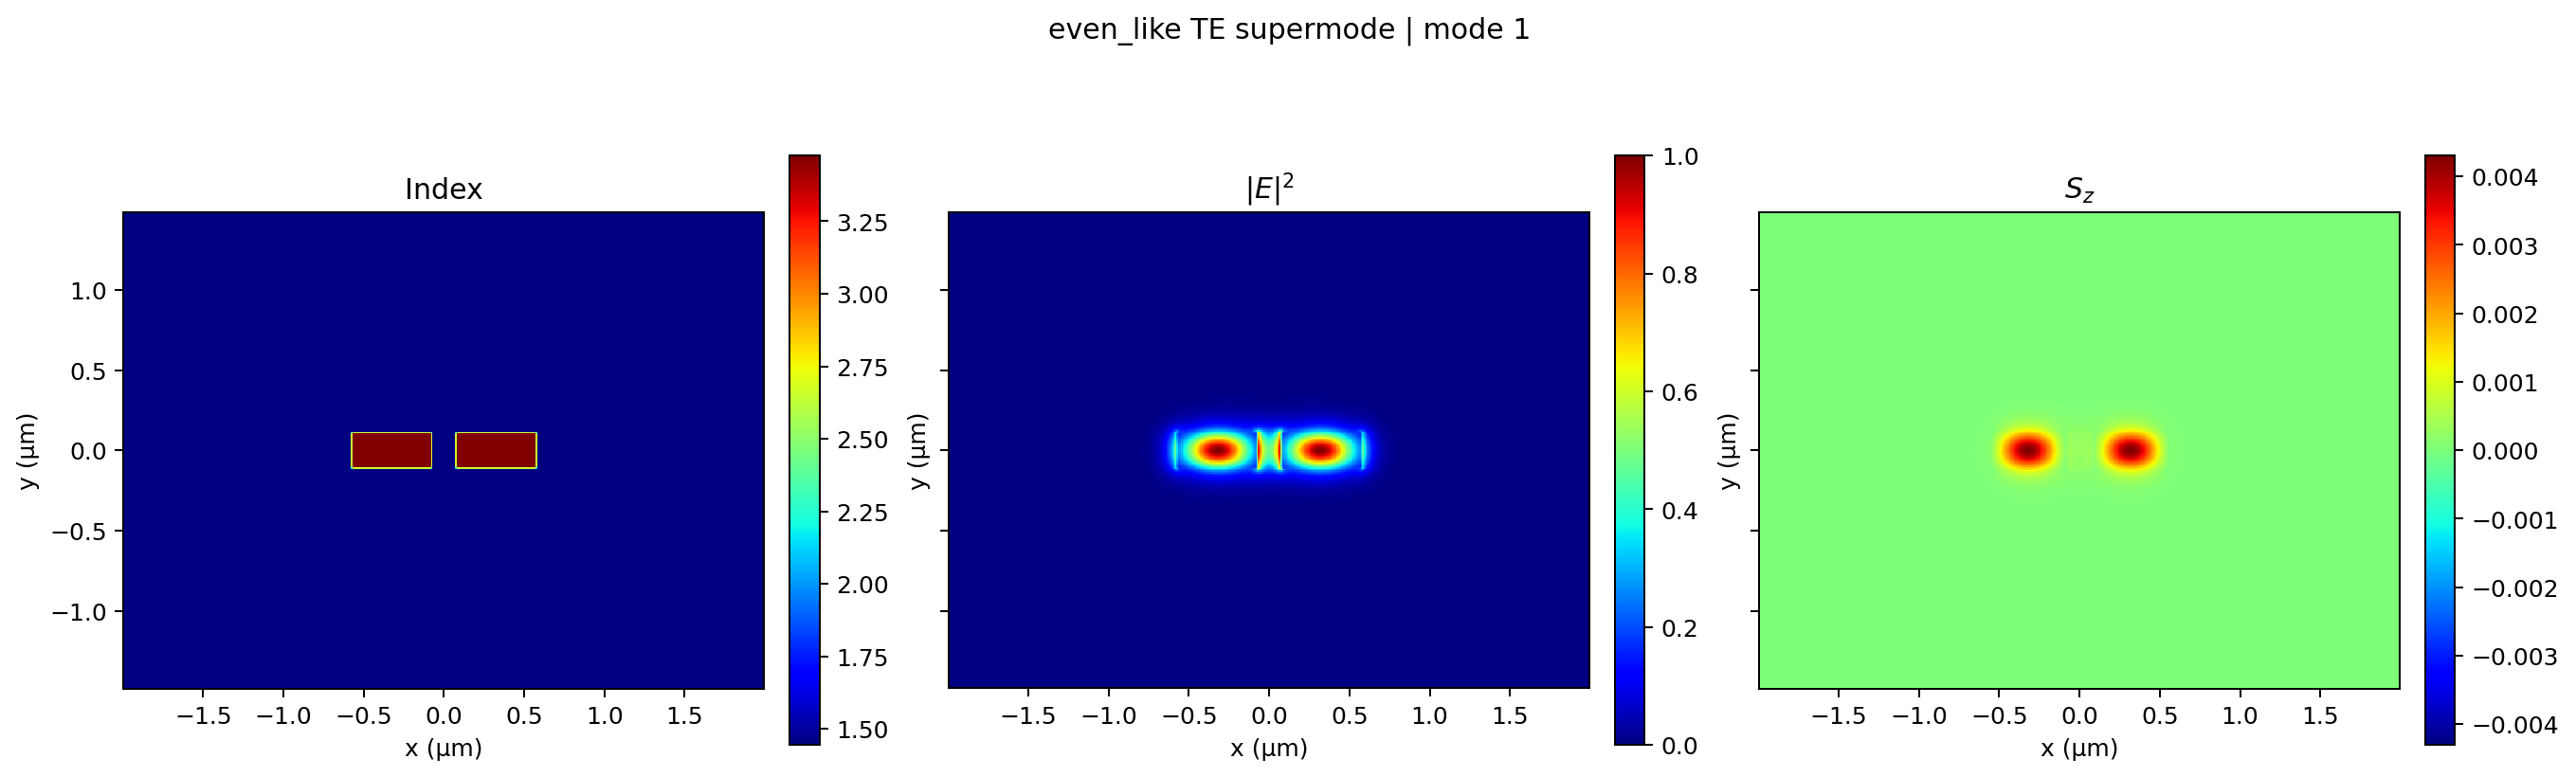

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\index_E2_Sz_even_like_mode_1.png


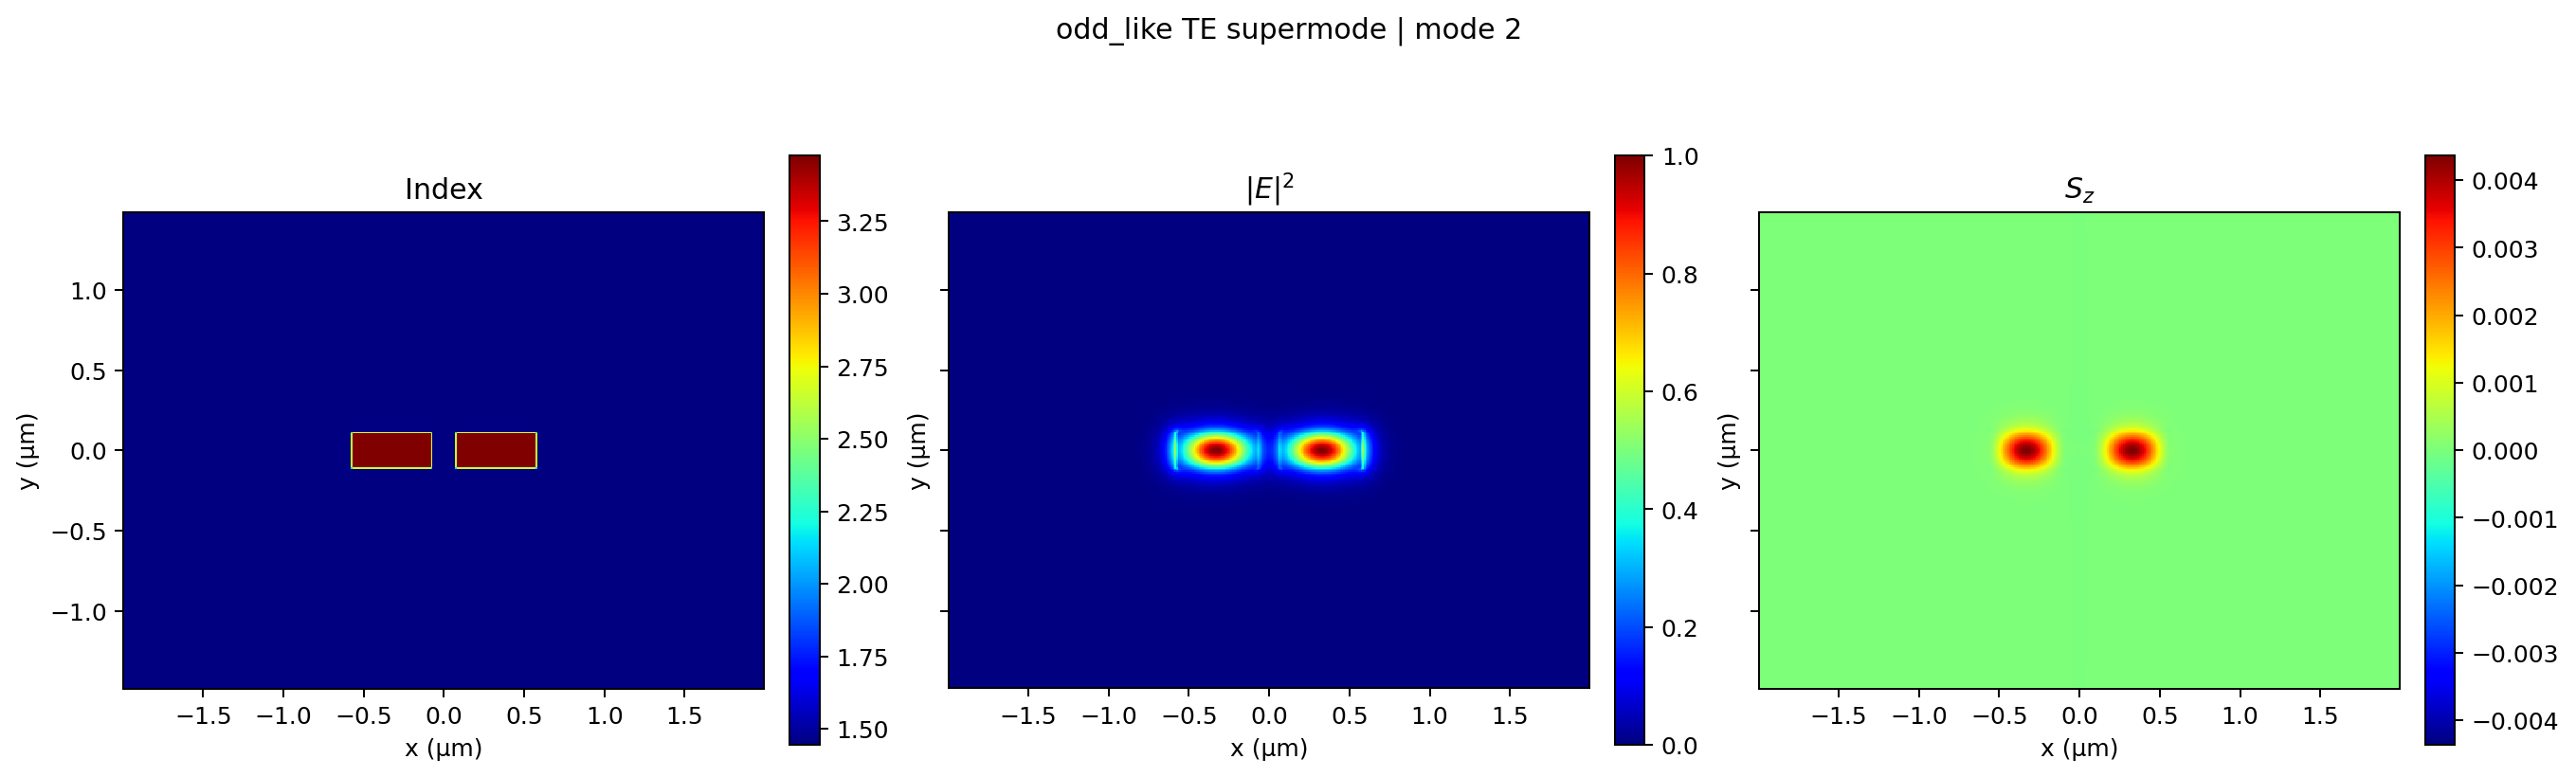

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\index_E2_Sz_odd_like_mode_2.png


In [17]:
def plot_index_E2_Sz(mode_number, mode_label):
    d = get_supermode_fields(mode_number)

    x = d["x"]
    y = d["y"]

    x_window = settings["plot_window_x_um"]
    y_window = settings["plot_window_y_um"]

    plot_items = [
        (d["n"], "Index", None),
        (d["E2"], r"$|E|^2$", "positive"),
        (d["Sz"], r"$S_z$", "signed"),
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.8),
        dpi=180,
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )

    for ax, (data, title, kind) in zip(axes.flat, plot_items):
        x_win, y_win, data_win = apply_window(
            x,
            y,
            data,
            x_window,
            y_window,
        )

        if kind == "signed":
            vmax = np.nanmax(np.abs(data_win))
            if not np.isfinite(vmax) or vmax == 0:
                vmax = 1.0

            im = ax.pcolormesh(
                x_win,
                y_win,
                data_win.T,
                shading="auto",
                cmap=settings["cmap"],
                vmin=-vmax,
                vmax=vmax,
            )

        else:
            im = ax.pcolormesh(
                x_win,
                y_win,
                data_win.T,
                shading="auto",
                cmap=settings["cmap"],
            )

        ax.set_title(title)
        ax.set_xlabel("x (µm)")
        ax.set_ylabel("y (µm)")
        ax.set_aspect("equal")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        f"{mode_label} TE supermode | mode {mode_number}",
        y=1.03,
    )

    save_path = plot_dir / f"index_E2_Sz_{mode_label}_mode_{mode_number}.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


for mode_number, mode_label in modes_to_plot:
    plot_index_E2_Sz(mode_number, mode_label)

## Even/odd verification using Re(Ex)

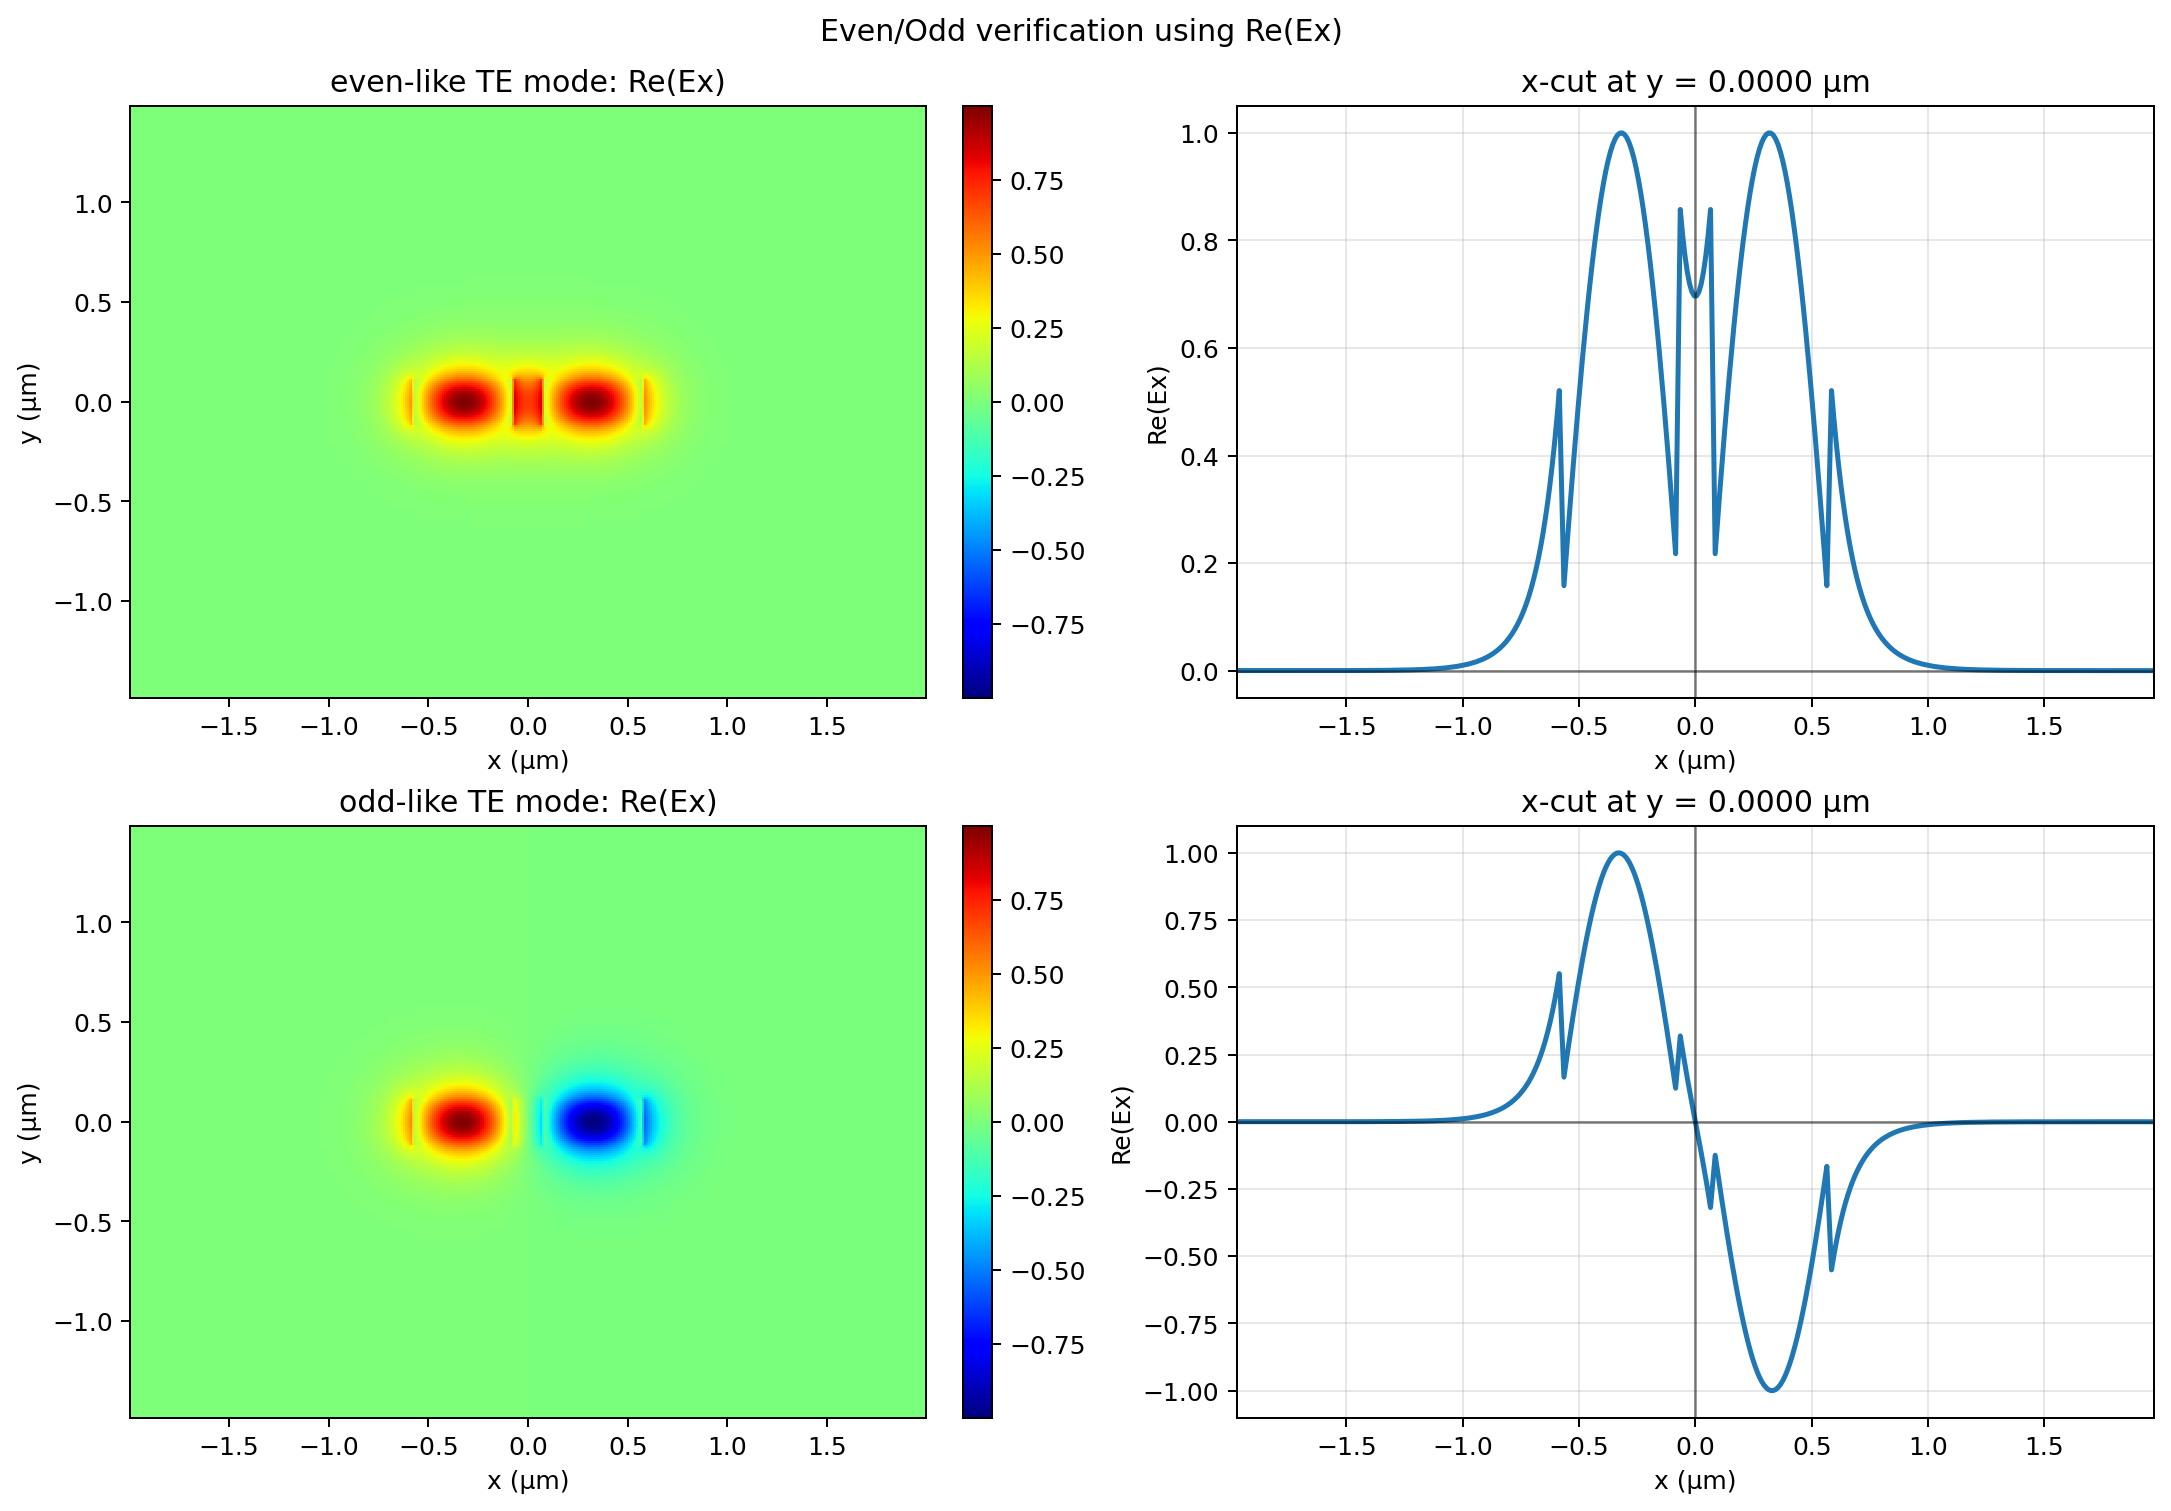

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\even_odd_Re_Ex.png


In [18]:
def get_xcut_at_y0(field, y):
    y0_index = int(np.argmin(np.abs(y - 0.0)))
    return field[:, y0_index], y[y0_index]


def plot_even_odd_verification(field_name="Ex"):
    d_even = get_supermode_fields(even_mode_number)
    d_odd = get_supermode_fields(odd_mode_number)

    x = d_even["x"]
    y = d_even["y"]

    x_window = settings["plot_window_x_um"]
    y_window = settings["plot_window_y_um"]

    x_mask = (x >= x_window[0]) & (x <= x_window[1])
    y_mask = (y >= y_window[0]) & (y <= y_window[1])

    x_win = x[x_mask]
    y_win = y[y_mask]

    mode_items = [
        (d_even, even_mode_number, "even-like TE mode"),
        (d_odd, odd_mode_number, "odd-like TE mode"),
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8),
        dpi=180,
        constrained_layout=True,
    )

    for row, (d, mode_number, mode_label) in enumerate(mode_items):
        field = np.real(d[field_name])
        field_win = field[np.ix_(x_mask, y_mask)]

        vmax = np.nanmax(np.abs(field_win))

        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        im = axes[row, 0].pcolormesh(
            x_win,
            y_win,
            field_win.T,
            shading="auto",
            cmap=settings["cmap"],
            vmin=-vmax,
            vmax=vmax,
        )

        axes[row, 0].set_title(f"{mode_label}: Re({field_name})")
        axes[row, 0].set_xlabel("x (µm)")
        axes[row, 0].set_ylabel("y (µm)")
        axes[row, 0].set_aspect("equal")
        fig.colorbar(im, ax=axes[row, 0], fraction=0.046, pad=0.04)

        field_cut, y_used = get_xcut_at_y0(field, y)

        axes[row, 1].plot(x, field_cut, linewidth=2)
        axes[row, 1].axhline(0, color="k", linewidth=1, alpha=0.5)
        axes[row, 1].axvline(0, color="k", linewidth=1, alpha=0.5)
        axes[row, 1].set_xlim(x_win.min(), x_win.max())
        axes[row, 1].set_title(f"x-cut at y = {y_used:.4f} µm")
        axes[row, 1].set_xlabel("x (µm)")
        axes[row, 1].set_ylabel(f"Re({field_name})")
        axes[row, 1].grid(True, alpha=0.3)

    fig.suptitle(f"Even/Odd verification using Re({field_name})", y=1.03)

    save_path = plot_dir / f"even_odd_Re_{field_name}.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


plot_even_odd_verification("Ex")

## Even/odd verification using Re(Hy)

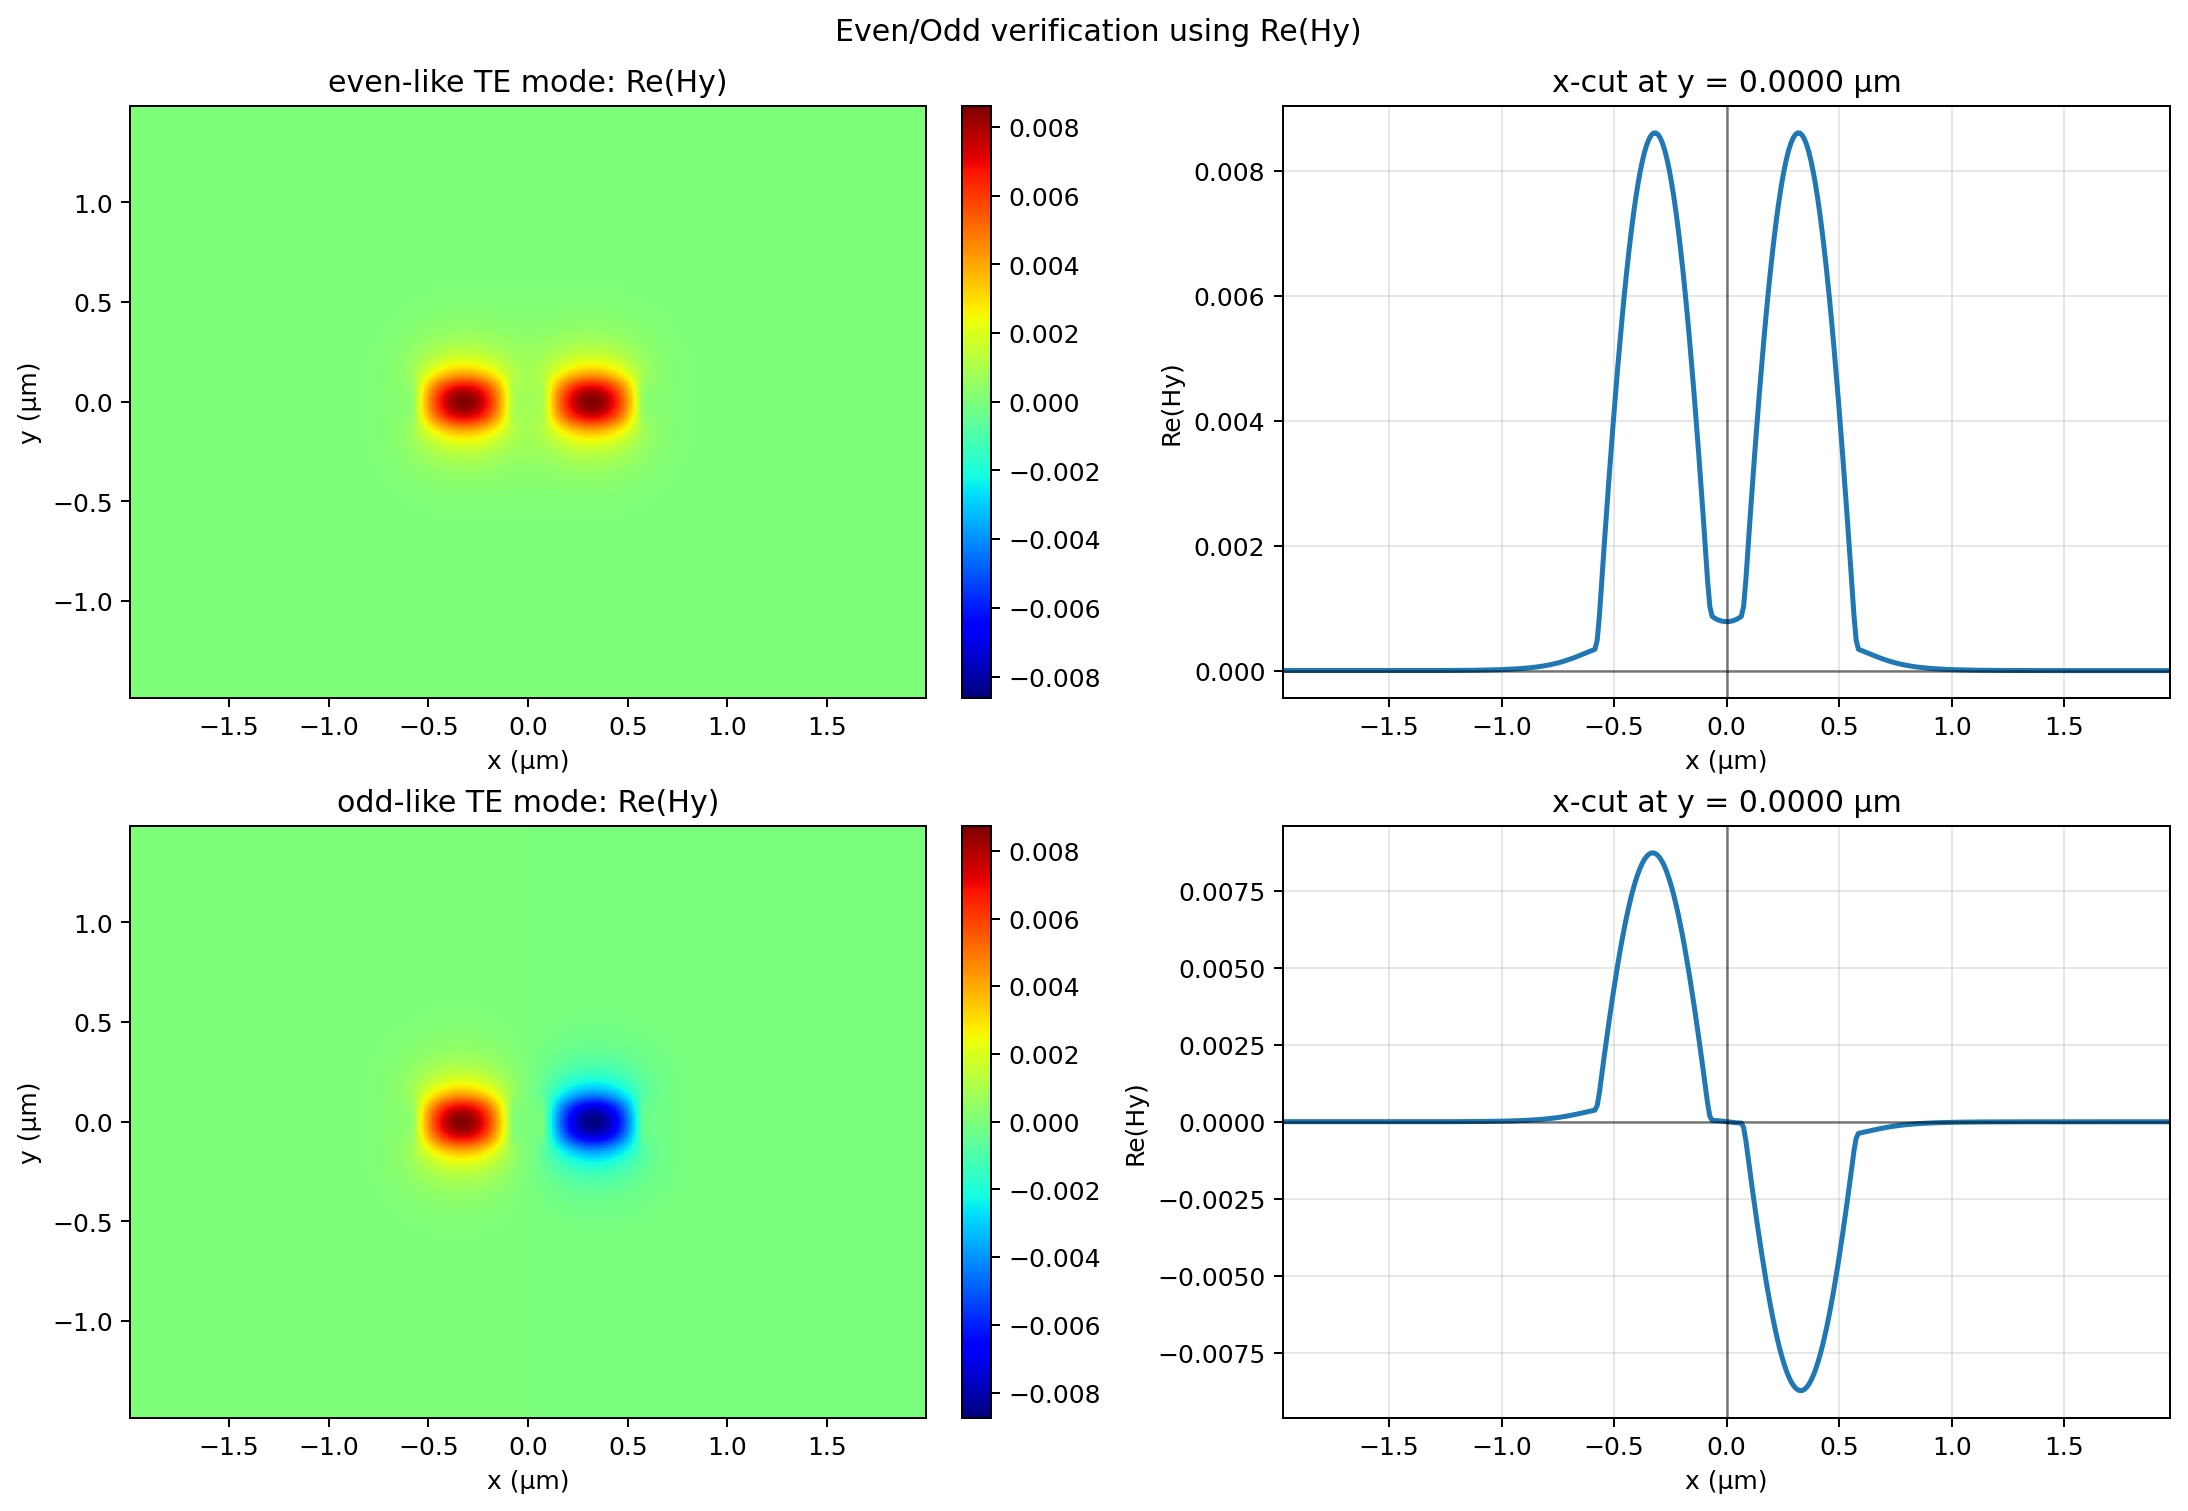

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots\even_odd_Re_Hy.png


In [19]:
plot_even_odd_verification("Hy")

## Final save summary

In [20]:
final_modes_df = modes_df.copy()

final_modes_path = run_dir / "final_modes_table.csv"
final_modes_df.to_csv(final_modes_path, index=False)

final_selected_path = run_dir / "final_selected_supermodes.csv"
selected_modes_df.to_csv(final_selected_path, index=False)

final_supermode_path = run_dir / "final_supermode_coupling_result.csv"
supermode_df.to_csv(final_supermode_path, index=False)

print("Saved final files:")
print("All modes:")
print(final_modes_path)
print()
print("Selected modes:")
print(final_selected_path)
print()
print("Supermode coupling:")
print(final_supermode_path)
print()
print("Plots folder:")
print(plot_dir)
print()
print("Fields folder:")
print(field_dir)

display(final_modes_df)
display(selected_modes_df)
display(supermode_df)

Saved final files:
All modes:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\final_modes_table.csv

Selected modes:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\final_selected_supermodes.csv

Supermode coupling:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\final_supermode_coupling_result.csv

Plots folder:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\plots

Fields folder:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_08\fields


,mode_number,neff,neff_real,neff_imag,loss_dB_per_cm,group_index,group_index_real,TE_polarization_fraction,waveguide_TE_fraction,waveguide_TE_TM_fraction
0,1,2.464566+0.000000j,2.464566075635981,1.0891767606995943e-17,3.834960e-10,4.120649+0.000000j,4.120649139782062,0.983702,NaN,NaN
1,2,2.432078-0.000000j,2.4320782972388253,-5.677275034059444e-17,-1.998952e-09,4.315760-0.000000j,4.315759607704647,0.985576,NaN,NaN


,label,mode_number,neff_real,TE_polarization_fraction,waveguide_TE_fraction,group_index_real,loss_dB_per_cm
0,even_like_assumed,1,2.464566075635981,0.983702,NaN,4.120649139782062,3.834960e-10
1,odd_like_assumed,2,2.4320782972388253,0.985576,NaN,4.315759607704647,-1.998952e-09


,wavelength_um,wg_width_um,wg_thickness_um,gap_um,n_even_assumed,n_odd_assumed,delta_n,L_full_power_um,L_full_power_mm,L_50_50_um,L_50_50_mm,even_assumed_mode_number,odd_assumed_mode_number,even_assumed_TE_polarization_fraction,odd_assumed_TE_polarization_fraction,even_assumed_group_index_real,odd_assumed_group_index_real,even_assumed_loss_dB_per_cm,odd_assumed_loss_dB_per_cm
0,1.55,0.5,0.22,0.15,2.464566,2.432078,0.032488,23.855125,0.023855,11.927562,0.011928,1,2,0.983702,0.985576,4.120649139782062,4.315759607704647,3.834960e-10,-1.998952e-09
